# DAF-18: The Board Paper — Final Test, Error Analysis, and the Model Card

## 📖 The story: Asha madam opens the sealed envelope

### Who is Asha madam, and what must she decide?

Asha madam is the coordinator of a school in Delhi. Delhi's air is sometimes very bad. The tiny dust in the air is measured as **PM2.5**. A higher number means worse air, and **91 or more is "Poor"**. Children should not stand outside on a Poor day.

Every evening at 6 pm she must decide one thing:

> **Tomorrow morning, will the 600 children stand outside for assembly, or stay indoors?**

To decide, she needs a guess of **tomorrow's PM2.5**.

### Two ways she can guess

| | Way 1: her old method | Way 2: her model |
|---|---|---|
| Name | **Persistence** | **Ridge** (a small machine-learning model) |
| How it guesses | She looks at today's 5 pm reading and says, *"Tomorrow will be about the same."* | The computer looks at today's reading and the average of the last 3, 7 and 14 days, and predicts tomorrow's number |
| Cost | Free, no computer | Needs training, a file to save, a service to run |

The whole project asks one question: **is Way 2 really better than Way 1?** If it is not, why keep the computer?

### What she has done so far (a school comparison)

| Ticket | What happened | Like in school |
|---|---|---|
| DAF-14 to DAF-16 | She built the model and tried it | Learning the chapters and writing practice tests |
| DAF-17 | She tried the settings (the "knobs") using only the 251 **study days**. Then she wrote her final choice in `models/final_config.json` and **signed** it | Finishing preparation, writing the final study plan on paper, and signing it |
| **DAF-18 (now)** | She opens the **130 test days** (from 1 March 2026) | **The real board exam paper** |

Those 130 test days are the **sealed envelope**. The model has never been allowed to learn from them. That is why they can give an honest answer.

### The problem

The principal asks three plain questions:

> *"Does your model beat your old method? By how much? And on which days should I not trust it?"*

Asha madam is nervous. In the mock tests (DAF-17), her model won only a little: an average mistake of 36.5 against persistence's 37.9. That is a win of only about 1.4 out of about 37, which is far below the 10% the project asked for.

Now the envelope is on the table, and she feels a temptation:

```text
1. She opens the envelope and sees a poor score.
2. She quietly changes one setting.
3. She opens the envelope again. The score looks better.
4. She tells the principal the second score.
```

### What Sharma sir says

Sharma sir, the old maths teacher, stops her.

> *"Beta, the paper opens once. If the marks are poor, write the poor marks in the report card. A student who retakes the board paper until the marks look good has not passed. She has only learned the paper."*

**Why he is right.** The first score is the only honest one. The moment you change something because of what the test showed you, the test days have started to teach your model. They are no longer a fair test, like a student who has seen the question paper before the exam.

### So what do we do in this ticket?

```text
Open the envelope ONCE
   -> compare the model with persistence on the SAME 130 days
   -> say "met" or "not met" for each of the two pass marks
   -> open the answer sheet: which 10 days did we lose the most marks on, and why?
   -> write a one-page model card so that anyone can see where NOT to trust it
```

### One honest note

The test days were already looked at in earlier tickets (DAF-06 to DAF-16). So the envelope was not perfectly sealed. This is written down in decision D-007. It is why this notebook calls DAF-18 **the last look** at the test days, **not the first**, and why the model card must say it too.

## 🎯 The exact problem

> **How do we score the frozen model once, say honestly whether it met the goal, find the days where it fails, and write that down so that anyone who uses the model knows its limits?**

The answer is four things: **one test run**, **a verdict** against the two success rules, **the ten worst days**, and **a model card**.


## What this ticket is about

No new model and no new settings. This ticket only **measures and reports**.

```text
DAF-17 ended with                        DAF-18 ends with
a frozen recipe (Ridge, alpha=1.0)       the recipe trained on all 251 train days
CV scores on 251 train days              ONE score on the 130 test days
"probably a bit better than persistence" a verdict: met / not met, with numbers
no idea where it fails                   ten worst days, each with a reason
a JSON file                              a saved model + a model card
```

The success rules come from `docs/requirements.md`. Both must hold:

| Rule | Meaning |
|---|---|
| MAE at least **10% lower** than persistence | the average mistake is clearly smaller |
| Recall on Poor-or-worse days **not lower** than persistence | it must not miss more smoggy days than the old method |

Poor means PM2.5 of 91 µg/m³ or more.

## The new ideas

| Idea | One line | Where it comes from |
|---|---|---|
| Final test run | Fit on all train rows, predict the locked test rows, score them **once** | the frozen recipe in `models/final_config.json` |
| Verdict | A plain "met" or "not met" for each success rule, with the numbers next to it | `docs/requirements.md` |
| Error analysis | Sort the test days by how wrong we were and look at the worst ten | pandas `sort_values` |
| `joblib` | Save a fitted model to one file and load it again later, even in another Python session | `joblib.dump` / `joblib.load` |
| Model card | A one-page note that travels with the model: purpose, data, features, metrics, threshold, failure cases, do-not-use limits | `docs/model_card.md` |

DAF-16 (walk-forward) is reported next to the test score as a second opinion. It is **not** a second test.

## What we start with

Everything the model needs was decided in DAF-17 and is in `models/final_config.json`:

| Item | Frozen value |
|---|---|
| Model | `StandardScaler` then `Ridge(alpha=1.0, solver="lsqr")` |
| Features | `pm25_until_17`, `mean_3`, `mean_7`, `mean_14` |
| Train rows | 251 days, 17 Mar 2025 – 28 Feb 2026 |
| Locked test | 130 days, from 1 Mar 2026 |
| Poor line | 91 µg/m³ |
| Cross-validation (train days only) | Ridge 36.456 vs persistence 37.889 MAE, about **3.8% better** |

That last row is a warning to ourselves, written **before** we open the envelope: 3.8% is far below the 10% target. The test result may well say "not met". That is a valid outcome of this ticket.

## Rules for this ticket

- **Read the recipe from the file.** The model is rebuilt from `models/final_config.json`. Nothing is typed in again by hand.
- **One scoring.** The test rows are predicted once, in one cell. No second attempt, no "just checking" with a small change.
- **Write the verdict rule first.** The two success rules are copied into the notebook before the score is computed.
- **Persistence on the same rows.** The baseline is scored on exactly the same 130 days, otherwise the comparison is unfair.
- **Be honest about history.** The test days were already looked at in DAF-06 to DAF-16 (D-007 says so). This is the last look at them, not the first, and the model card must say that.
- **Report what happened.** If the model loses, the report says it loses.

## The plan, one step at a time

This is the proposed plan. Each step is added to this notebook only when we start it.

1. Rebuild the train and test tables from the frozen config. Check the fingerprint so we know the recipe and data are the ones DAF-17 froze.
2. Write the verdict rules in the notebook, before any score exists.
3. Train Ridge on all 251 train rows. Score the 130 test rows **once**, with persistence beside it.
4. Put the walk-forward result from DAF-16 next to the test result.
5. Verdict: criterion 1 (MAE) and criterion 2 (recall), each with its numbers.
6. Error analysis: the ten worst test days, with date, actual, forecast, persistence forecast, and a likely reason.
7. Save the model with `joblib` in `models/pm25_station17_v1.joblib`, with the feature list and training date range. Load it in a fresh Python process and check that it reproduces one test prediction.
8. Write `docs/model_card.md`.
9. Log the rows in `reports/experiments.csv`.

The pictures for each step go in `18_visual_walkthrough.ipynb`, the same way `17_visual_walkthrough.ipynb` went with DAF-17.

## Acceptance criteria (from the ticket)

- [ ] The test set is scored exactly once — the notebook shows no second attempt
- [ ] The verdict answers both success criteria with numbers
- [ ] The ten-worst-days table exists with reasons
- [ ] The model file loads in a fresh Python session and reproduces one test prediction
- [ ] `docs/model_card.md` has every section in step 5 of the ticket

## Explain back (answered at the end)

1. Did the model meet the success criteria? If not, what is the most likely reason, and what would you try next?
2. What would you tell Asha about when not to trust the forecast?

# Step 1 — Take out the signed recipe and check nobody changed the book

## 🎬 How we got here

DAF-17 ended with a signature. The recipe for the final model is in `models/final_config.json`, and the 130 test days are still in the envelope.

---

**Sharma sir:** Beta, the exam hall is open. What do you bring in?

**Asha:** The signed recipe, sir. `final_config.json`. Ridge, `alpha = 1.0`, four features.

**Sharma sir:** Will you type the recipe again from memory?

**Asha:** No sir. I read it from the file. If I type it again I might type `alpha = 0.5` by mistake, and then I am testing a different student.

**Sharma sir:** Good. And the study book: the 251 train days. How do you know it is the same book you studied from in DAF-17?

**Asha:** In DAF-17 I took a fingerprint of the train answers, the `target_sha256`. I make the fingerprint again now. If even one number changed, the fingerprint is completely different.

**Sharma sir:** And the envelope?

**Asha:** I cut the table at 1 March 2026. The test rows go into a table called `test`. I count them, 130, but I do not print a single answer from it. It stays closed until Step 3.

---

## 😖 The problem

Three things could quietly be different from DAF-17, and none of them gives an error:

| What could change | How it would happen | What goes wrong |
|---|---|---|
| The recipe | typing the settings again by hand | we test a model nobody chose |
| The study data | someone re-ran the cleaning, or the CSV was edited | the model learns from different days than the ones tuned on |
| The cut | a different date or a different `dropna` | the test set is not the 130 days we promised |

## 💡 The fix

Read **everything** from the config file, rebuild the table the same way DAF-17 did, and check it against the config with `assert`. If any check fails, the notebook stops before the envelope opens.

**What "done" looks like:** 251 train rows with the same fingerprint, 130 test rows counted but not looked at, and an unfitted model built from the file.

In [1]:
import hashlib
import json
from pathlib import Path

import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from delhi_air.clean import add_rolling_features   # our own function, the same one DAF-14 to DAF-17 used

# --- 1. Find the project folder (works from the repo root or from the project) -------------
CONFIG = "models/final_config.json"
project_root = next(
    candidate / sub
    for candidate in (Path.cwd(), *Path.cwd().parents)
    for sub in ("", "18_Projects/01_Delhi_Air_Forecast")
    if (candidate / sub / CONFIG).is_file()
)

# --- 2. Read the signed recipe: every setting comes from this file -------------------------
config = json.loads((project_root / CONFIG).read_text())
feature_names = config["features"]                         # the four inputs
TARGET = config["target"]                                  # "target" = tomorrow's 24-hour mean PM2.5
POOR_LINE = config["poor_line"]                            # 91 µg/m³
CUT_DATE = pd.Timestamp(config["locked_test"]["cut_date"]) # 1 March 2026

# --- 3. Rebuild the daily table exactly as DAF-17 did --------------------------------------
daily = pd.read_csv(project_root / "data/interim/daily_17.csv", parse_dates=["date"], index_col="date")
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()
full_table = add_rolling_features(daily)[feature_names + [TARGET]].dropna()

# --- 4. The cut: study days and the sealed envelope ----------------------------------------
train = full_table.loc[full_table.index < CUT_DATE].copy()
test = full_table.loc[full_table.index >= CUT_DATE].copy()   # sealed: counted here, used only in Step 3

# --- 5. Check the book is the same book: fingerprint, rows, dates ---------------------------
fingerprint = hashlib.sha256(train[TARGET].round(6).to_numpy().tobytes()).hexdigest()
assert fingerprint == config["train"]["target_sha256"], "the train data changed since DAF-17 froze the recipe"
assert len(train) == config["train"]["rows"], "not the 251 train rows of DAF-17"
assert str(train.index.min().date()) == config["train"]["first_date"], "train starts on a different day"
assert str(train.index.max().date()) == config["train"]["last_date"], "train ends on a different day"
assert len(test) == config["locked_test"]["rows_not_used"], "not the 130 locked test rows"

# --- 6. Rebuild the model from the file and nothing else ------------------------------------
def build_model(config):
    """Make an unfitted model from the config file. Same function as DAF-17 Step 7."""
    parts = {"StandardScaler": StandardScaler, "Ridge": Ridge}
    steps = [(f"step{i}", parts[kind](**settings)) for i, (kind, settings) in enumerate(config["model"]["steps"])]
    return Pipeline(steps) if len(steps) > 1 else steps[0][1]

model = build_model(config)

print(f"recipe     : signed by {config['ticket']} on {config['frozen_on']}  ->  {model}")
print(f"features   : {feature_names}")
print(f"fingerprint: {fingerprint[:16]}...  matches the config")
print(f"train      : {len(train)} rows  ({train.index.min().date()} to {train.index.max().date()})")
print(f"test       : {len(test)} rows  ({test.index.min().date()} to {test.index.max().date()})  - sealed, no answer printed")

recipe     : signed by DAF-17 on 2026-10-03  ->  Pipeline(steps=[('step0', StandardScaler()), ('step1', Ridge(solver='lsqr'))])
features   : ['pm25_until_17', 'mean_3', 'mean_7', 'mean_14']
fingerprint: 4becfde856706a34...  matches the config
train      : 251 rows  (2025-03-17 to 2026-02-28)
test       : 130 rows  (2026-03-01 to 2026-08-25)  - sealed, no answer printed


### What this code does, line by line

**Part 1 — find the project folder**

| Line | What it does |
|---|---|
| `CONFIG = "models/final_config.json"` | The signed recipe. Its path is written once and reused |
| `project_root = next(candidate / sub for candidate in (...) for sub in (...) if ...)` | Try the current folder and every folder above it. In each, try two places: right here (`""`) and inside `18_Projects/01_Delhi_Air_Forecast`. `next(...)` gives the first place where the config file exists. So the notebook runs from the repo root **or** from the project, with no absolute path |

**Part 2 — read the recipe**

| Line | What it does |
|---|---|
| `config = json.loads((project_root / CONFIG).read_text())` | Read the file as text, then turn the JSON into a Python dictionary |
| `feature_names = config["features"]` | The four features, as DAF-17 wrote them |
| `TARGET`, `POOR_LINE`, `CUT_DATE` | Three more values from the file. Capital letters mean "never changes in this notebook" |

**Part 3 — rebuild the table**

| Line | What it does |
|---|---|
| `pd.read_csv(..., parse_dates=["date"], index_col="date")` | The daily table, with real dates as row labels |
| `tz_convert("Asia/Kolkata").tz_localize(None)` and `.normalize()` | Make each label a plain Delhi calendar day at midnight, same as DAF-17 |
| `add_rolling_features(daily)[feature_names + [TARGET]].dropna()` | Add `mean_3`, `mean_7`, `mean_14`, keep the four features and the target, drop incomplete rows. 381 rows |

**Part 4 — the cut**

| Line | What it does |
|---|---|
| `train = full_table.loc[full_table.index < CUT_DATE].copy()` | Study days: everything before 1 March 2026 |
| `test = full_table.loc[full_table.index >= CUT_DATE].copy()` | The envelope: 1 March 2026 onwards. DAF-17 deleted these rows. Here we need them, but only in Step 3 |

**Part 5 — the checks**

| Line | What it does |
|---|---|
| `hashlib.sha256(train[TARGET].round(6).to_numpy().tobytes()).hexdigest()` | The same fingerprint recipe as DAF-17: round to 6 decimals, turn into raw bytes, hash. Same data gives the same 64-character code |
| `assert fingerprint == config["train"]["target_sha256"], "..."` | If one train answer changed, the codes differ and the notebook stops |
| the next four `assert` lines | Same number of train rows, same first and last date, same 130 test rows |

**Part 6 — the model**

| Line | What it does |
|---|---|
| `def build_model(config):` | Copied from DAF-17 Step 7: turns the text recipe into a real sklearn object |
| `parts = {"StandardScaler": StandardScaler, "Ridge": Ridge}` | A lookup from the name in the JSON to the Python class |
| `parts[kind](**settings)` | Create the class with its settings. `**settings` turns `{"solver": "lsqr", "alpha": 1.0}` into `Ridge(solver="lsqr", alpha=1.0)` |
| `Pipeline(steps) if len(steps) > 1 else steps[0][1]` | Two steps (scaler, then Ridge) become one `Pipeline`, so the scaler is always applied before Ridge |
| `model = build_model(config)` | An **unfitted** model. It has not learned anything yet |
| the `print` lines | A summary. For `test` we print only the count and the dates, never a target value |

### Read the result

| Check | Result |
|---|---|
| Recipe | read from the file: `StandardScaler` then `Ridge(alpha=1.0, solver="lsqr")` |
| Fingerprint of the 251 train answers | same as in DAF-17 ✅ |
| Train rows and dates | 251, 17 Mar 2025 to 28 Feb 2026 ✅ |
| Test rows | 130, from 1 Mar 2026 ✅, nothing printed from them |

All five `assert` lines passed, so this is exactly the student and the book that DAF-17 signed. If one of them had failed, the right move would be to stop and find out what changed, **not** to update the config.

## Before Step 2

The model exists but has not learned anything, and the envelope is still closed. Before it opens, the pass marks go on the blackboard.

# Step 2 — Write the pass marks on the blackboard, before the paper opens

## 🎬 How we got here

Step 1 checked the recipe and the book. Everything matches. Asha madam's hand is on the envelope.

---

**Sharma sir:** Wait. What is the pass mark?

**Asha:** Sir, it is in `docs/requirements.md`. The average mistake must be at least 10% smaller than persistence. And the model must not miss more Poor days than persistence.

**Sharma sir:** It is in a document. Is it in the notebook?

**Asha:** Not yet.

**Sharma sir:** Then write it in the notebook first, as code. Why do you think I insist?

**Asha:** Because if the result is 8%, I might say "8% is nearly 10%, it is fine".

**Sharma sir:** *(smiles)* Every student does that. The rule written after the marks always bends toward the marks. One more thing. Your rule is code. How do you know the code is right, before the real marks exist?

**Asha:** I run it on the toy from the walkthrough, sir. There I calculated by hand: persistence 19.0, Ridge 13.8, 27% better, recall 2 of 3 each. If the code gives the same, it is right.

---

## 😖 The problem

The rules exist in words. Words can be read in a friendly way after the result is known. And a scoring function with a bug (for example, `>` instead of `>=` at the Poor line) would quietly change the verdict.

## 💡 The fix

1. Put both rules in code, with the number `0.10` written as a constant.
2. Write two small functions: `score(...)` gives the marks of one student, `judge(...)` applies the two rules.
3. Test both functions on the toy numbers, where we already know the answer by hand.

| Rule | In code |
|---|---|
| 1 · MAE | `(persistence MAE − Ridge MAE) ÷ persistence MAE >= 0.10` |
| 2 · Recall on Poor days | `Ridge recall >= persistence recall`, with Poor meaning `actual >= 91`, and a "warning" meaning `forecast >= 91` |

**Both** must be true for the verdict **MET**.

In [2]:
# Continues from Step 1: POOR_LINE.
# --- 1. The two pass marks, copied from docs/requirements.md BEFORE any test score exists ------
MIN_MAE_IMPROVEMENT = 0.10   # rule 1: Ridge's MAE must be at least 10% lower than persistence's
                             # rule 2: Ridge's recall on Poor days must not be lower than persistence's

# --- 2. The marks of one student ------------------------------------------------------------
def score(actual, forecast):
    """MAE, and how the forecast did on the really Poor days (actual >= POOR_LINE)."""
    really_poor = actual >= POOR_LINE
    warned = forecast >= POOR_LINE                     # the forecast says "stay indoors"
    return {
        "MAE": (forecast - actual).abs().mean(),
        "Poor days": int(really_poor.sum()),
        "caught": int((really_poor & warned).sum()),
        "missed": int((really_poor & ~warned).sum()),
        "false alarms": int((~really_poor & warned).sum()),
        "recall": (really_poor & warned).sum() / really_poor.sum(),
    }

# --- 3. The verdict: apply both rules -------------------------------------------------------
def judge(ridge, persistence):
    improvement = (persistence["MAE"] - ridge["MAE"]) / persistence["MAE"]
    rule_1 = improvement >= MIN_MAE_IMPROVEMENT
    rule_2 = ridge["recall"] >= persistence["recall"]
    return improvement, rule_1, rule_2

# --- 4. Test the rules on the toy, where the answer is known by hand ------------------------
toy_actual      = pd.Series([70, 120, 130, 95, 90])    # days A to E of the walkthrough
toy_persistence = pd.Series([60, 100, 150, 80, 120])
toy_ridge       = pd.Series([68, 100, 140, 84, 116])
toy_r, toy_p = score(toy_actual, toy_ridge), score(toy_actual, toy_persistence)
toy_improvement, toy_rule_1, toy_rule_2 = judge(toy_r, toy_p)

assert round(toy_p["MAE"], 1) == 19.0 and round(toy_r["MAE"], 1) == 13.8, "MAE does not match the hand sums"
assert toy_p["caught"] == toy_r["caught"] == 2 and toy_r["Poor days"] == 3, "recall does not match the hand sums"
assert toy_rule_1 and toy_rule_2, "the toy should pass both rules"
assert score(pd.Series([91.0]), pd.Series([91.0]))["caught"] == 1, "exactly 91 must count as Poor and as a warning"

print(f"toy: MAE {toy_p['MAE']:.1f} -> {toy_r['MAE']:.1f} = {toy_improvement:.0%} better,"
      f" recall {toy_r['caught']} of {toy_r['Poor days']} each  ->  rule 1 {toy_rule_1}, rule 2 {toy_rule_2}")
print(f"Pass marks are on the blackboard: MAE at least {MIN_MAE_IMPROVEMENT:.0%} lower, recall not lower.")

toy: MAE 19.0 -> 13.8 = 27% better, recall 2 of 3 each  ->  rule 1 True, rule 2 True
Pass marks are on the blackboard: MAE at least 10% lower, recall not lower.


### What this code does, line by line

| Line | What it does |
|---|---|
| `MIN_MAE_IMPROVEMENT = 0.10` | Rule 1 as a number: 10%. Written once, in capitals, before the test exists |
| `def score(actual, forecast):` | Give it the real values and one student's forecasts, get back that student's marks |
| `really_poor = actual >= POOR_LINE` | True for each day that was really Poor (91 or more) |
| `warned = forecast >= POOR_LINE` | True for each day where the forecast says 91 or more. That is the day Asha keeps the children indoors |
| `"MAE": (forecast - actual).abs().mean()` | Mistake per day, sign removed with `.abs()`, then the average |
| `"caught": int((really_poor & warned).sum())` | `&` = both true: Poor **and** warned. Counting the True values gives the caught days |
| `"missed": ... really_poor & ~warned` | `~` flips True and False. Poor but **not** warned: children stood in smog |
| `"false alarms": ... ~really_poor & warned` | Not Poor, but warned: children stayed in for nothing |
| `"recall": caught ÷ all Poor days` | The share of Poor days that were warned about |
| `def judge(ridge, persistence):` | Takes two mark sheets, returns the improvement and the answer to each rule (`True` or `False`) |
| `improvement = (persistence["MAE"] - ridge["MAE"]) / persistence["MAE"]` | How much smaller Ridge's mistake is, as a share of persistence's mistake |
| `toy_actual`, `toy_persistence`, `toy_ridge` | Days A to E from the walkthrough, where the sums were done by hand |
| `assert round(toy_p["MAE"], 1) == 19.0 and ...` | The code must give 19.0 and 13.8, the hand answers |
| `assert toy_p["caught"] == toy_r["caught"] == 2 and ...` | Both caught 2 of the 3 Poor days, as on the hand page |
| `assert score(pd.Series([91.0]), pd.Series([91.0]))["caught"] == 1` | The edge case: a reading of exactly 91 is Poor, and a forecast of exactly 91 is a warning. This catches a `>` instead of `>=` |

### Read the result

The functions give **19.0 and 13.8, 27% better, 2 of 3 caught each**: the same as the hand sums. All four `assert` lines passed, including the edge case at exactly 91. So the scoring code can be trusted **before** it sees a real test number.

The blackboard now says:

| Rule | Pass mark | Result |
|---|---|---|
| 1 · MAE | at least 10% lower than persistence | ? |
| 2 · Recall on Poor days | not lower than persistence | ? |

## Before Step 3

Recipe checked, pass marks written, scoring code tested. Now the envelope opens, once.

# Step 3 — Open the envelope, once

## 🎬 How we got here

| What we have | From |
|---|---|
| An unfitted Ridge, built from the signed file | Step 1 |
| 251 train days with the same fingerprint as DAF-17 | Step 1 |
| 130 sealed test days | Step 1 |
| `score(...)` and `judge(...)`, tested on the toy | Step 2 |

---

**Sharma sir:** Tell me the four moves before you start.

**Asha:** Cook, serve, old way, mark. I fit Ridge on all 251 study days. I predict the 130 test days. For persistence I just copy each day's `pm25_until_17`. Then I score both on the same 130 days.

**Sharma sir:** In DAF-06 persistence scored on 161 days. Will you take that number?

**Asha:** No sir. DAF-06 had no 14-day average, so it kept more days. Here 31 of those days are missing because `mean_14` was not ready. Different paper. Both students write **this** paper, the same 130 days.

**Sharma sir:** And if the marks look strange?

**Asha:** I write them down as they are. I do not change anything and run it again. Strange marks are for Step 6 to explain.

**Sharma sir:** Then open it.

---

## 😖 The problem

This is the only cell that touches the test answers. A notebook can be re-run, and a cell can be edited and run again. Nothing stops a second attempt except discipline.

## 💡 The fix

- All four moves happen in **one** cell.
- The first line of the cell refuses to run if `test_result` already exists. Running the cell a second time in the same session stops with an error.
- Persistence and Ridge are scored with the **same** `score(...)` function on the **same** rows.
- Every later step reads `test_result` and `scores`. None of them calls `model.predict` on the test days to compute a score again.

### 🤔 Before you run the code

In DAF-17 the mock tests said Ridge 36.5 against persistence 37.9 (3.8% better), and recall 97 against 96 of 106. The test months, March to August, look like the quiet folds where persistence was strong. Do you expect Ridge to reach 10% here?

,MAE,Poor days,caught,missed,false alarms,recall
ridge,15.588,17,12,5,11,0.706
persistence,16.791,17,8,9,12,0.471


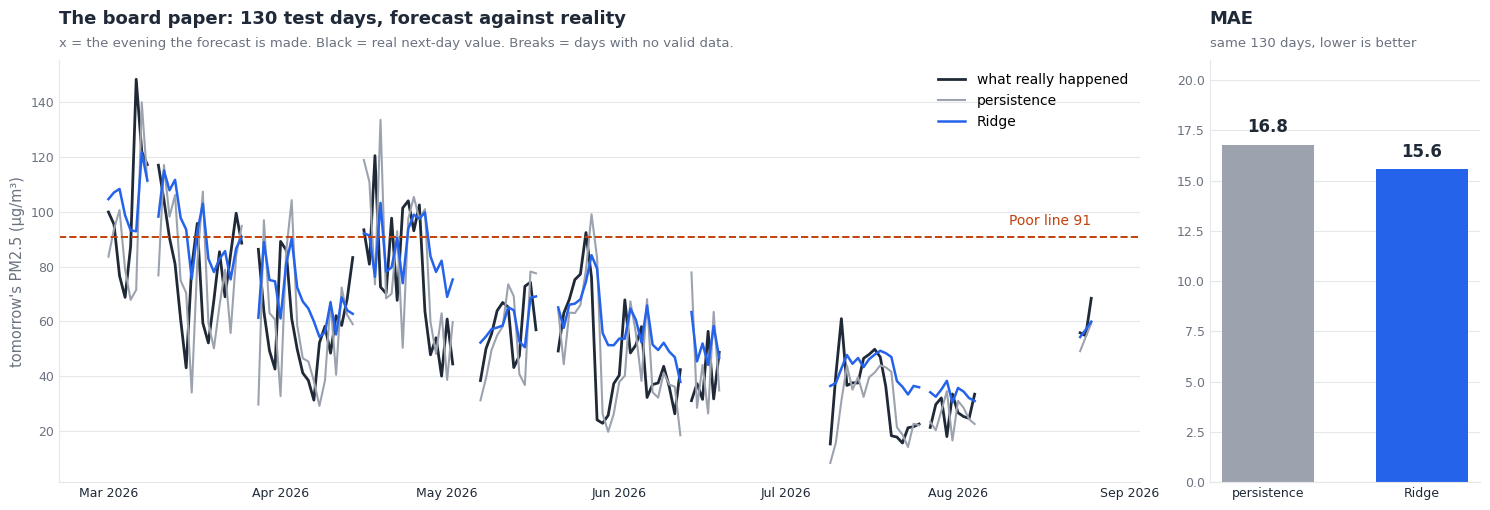

In [3]:
# Continues from Steps 1 and 2: train, test, model, feature_names, TARGET, POOR_LINE, score.
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

import recap_style as rs

assert "test_result" not in globals(), "The envelope is already open. The test days are scored once only."

# --- 1. COOK: fit on all 251 study days ----------------------------------------------------
model.fit(train[feature_names], train[TARGET])

# --- 2. SERVE + 3. OLD WAY: the one and only time the test answers are used ---------------
test_result = pd.DataFrame({
    "today_until_17": test["pm25_until_17"],                 # what Asha knows at 6 pm
    "actual": test[TARGET],                                  # what really happened tomorrow
    "ridge": model.predict(test[feature_names]),             # the model's forecast
    "persistence": test["pm25_until_17"],                    # the old way: tomorrow = today so far
})
test_result["ridge_error"] = test_result["ridge"] - test_result["actual"]               # + = forecast too high
test_result["persistence_error"] = test_result["persistence"] - test_result["actual"]

# --- 4. MARK: both students, same function, same 130 rows -----------------------------------
scores = pd.DataFrame({
    "ridge": score(test_result["actual"], test_result["ridge"]),
    "persistence": score(test_result["actual"], test_result["persistence"]),
}).T
display(scores.astype({"Poor days": int, "caught": int, "missed": int, "false alarms": int}).round(3))

# --- 5. Draw it: the 130 days, and the two MAE bars ------------------------------------------
fig, (line_ax, bar_ax) = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [4, 1]})
for column, colour, width, label in (("actual", rs.INK, 2.0, "what really happened"),
                                     ("persistence", rs.BAR, 1.5, "persistence"),
                                     ("ridge", rs.ACCENT, 1.8, "Ridge")):
    daily_line = test_result[column].asfreq("D")             # missing days become gaps, not straight lines
    line_ax.plot(daily_line.index, daily_line, color=colour, lw=width, label=label)
line_ax.axhline(POOR_LINE, color=rs.ALERT, ls="--", lw=1.4)
line_ax.text(test_result.index[-1], POOR_LINE + 3, f"Poor line {POOR_LINE}", ha="right", va="bottom", color=rs.ALERT, fontsize=10)
line_ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
line_ax.set_ylabel("tomorrow's PM2.5 (µg/m³)", fontsize=10.5, color=rs.MUTED)
line_ax.legend(frameon=False, fontsize=10, loc="upper right")
rs.style_axis(line_ax, "The board paper: 130 test days, forecast against reality",
              "x = the evening the forecast is made. Black = real next-day value. Breaks = days with no valid data.")

bars = bar_ax.bar(["persistence", "Ridge"], scores["MAE"][["persistence", "ridge"]], color=[rs.BAR, rs.ACCENT], width=0.6)
for bar in bars:
    bar_ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f"{bar.get_height():.1f}",
                ha="center", va="bottom", fontsize=12, fontweight="bold", color=rs.INK)
bar_ax.set_ylim(0, scores["MAE"].max() * 1.25)
rs.style_axis(bar_ax, "MAE", "same 130 days, lower is better")
plt.tight_layout(); plt.show()

### What this code does, line by line

**Part 0 — the guard**

| Line | What it does |
|---|---|
| `assert "test_result" not in globals(), "..."` | `globals()` lists every name alive in the notebook. If `test_result` already exists, this cell has run before, so it stops. This is the "paper opens once" rule in code |

**Part 1 — cook**

| Line | What it does |
|---|---|
| `model.fit(train[feature_names], train[TARGET])` | The pipeline learns. The scaler learns the average and spread of each feature from the **train** rows only, then Ridge learns its weights. This is the only `fit` in the notebook |

**Part 2 and 3 — serve, and the old way**

| Line | What it does |
|---|---|
| `test_result = pd.DataFrame({...})` | One table, one row per test day, with the date as the row label |
| `"today_until_17": test["pm25_until_17"]` | What Asha knows at 6 pm: today's average up to 5 pm |
| `"actual": test[TARGET]` | The real 24-hour mean of the **next** day. The answer key |
| `"ridge": model.predict(test[feature_names])` | Ridge's forecast. `predict` only uses what was learned in `fit`; it learns nothing new |
| `"persistence": test["pm25_until_17"]` | The old way. Nothing to fit, so it is just a copy of today's number |
| `test_result["ridge_error"] = test_result["ridge"] - test_result["actual"]` | Forecast minus reality. **Plus** means the forecast was too high (a false fright), **minus** means too low (a danger on smoggy days) |

**Part 4 — mark**

| Line | What it does |
|---|---|
| `pd.DataFrame({"ridge": score(...), "persistence": score(...)}).T` | Each `score(...)` returns a dictionary of marks. The `DataFrame` puts them side by side; `.T` (transpose) turns it so each student is a row |
| `.astype({...: int})` | Show the counts as whole numbers, not `17.0` |

**Part 5 — the picture**

| Line | What it does |
|---|---|
| `plt.subplots(1, 2, ..., gridspec_kw={"width_ratios": [4, 1]})` | Two panels side by side: a wide one for the days and a narrow one for the bars |
| `for column, colour, width, label in (...)` | Draw three lines with one loop: reality in black, persistence in grey, Ridge in blue |
| `test_result[column].asfreq("D")` | Put in every calendar day. Days that are missing from the table become empty (`NaN`), and matplotlib leaves a break there instead of drawing a straight line across the gap |
| `line_ax.axhline(POOR_LINE, ...)` | The red dashed Poor line at 91 |
| `mdates.DateFormatter("%b %Y")` | Dates on the x-axis as `Mar 2026` |
| `bar_ax.bar([...], scores["MAE"][["persistence", "ridge"]], ...)` | Two bars, each student's MAE |
| `bar_ax.text(..., f"{bar.get_height():.1f}", ...)` | Write the value on top of each bar |

### Read the result

**The envelope is open. These are the marks, written once.**

| On the same 130 test days | Ridge | Persistence |
|---|---:|---:|
| MAE (average mistake, µg/m³) | **15.59** | 16.79 |
| Really Poor days | 17 | 17 |
| Caught (warned, and it was Poor) | **12** | 8 |
| Missed (no warning, but it was Poor) | **5** | 9 |
| False alarms (warned, but it was not Poor) | 11 | 12 |
| Recall on Poor days | **0.706** | 0.471 |

**About the question before the code:** no, it did not reach 10%. Ridge's mistake is 1.2 µg/m³ smaller on an average day. That is a real but small win, about the same size as in the mock tests (1.4).

What the picture shows:

- **The grey line runs one day late.** Persistence copies today, so every rise and fall shows up one day after it happened. Look at early March: the black line jumps, and the grey jumps the next day.
- **The blue line is calmer and sits a little higher.** Ridge leans on the 7- and 14-day averages, so it moves less. In March and April that helps: it keeps warning during a smog spell even on a day when today's reading dips. That is where its extra 4 caught Poor days come from.
- **The breaks in the lines** are days with no valid data (fewer than 18 hourly readings, or not enough history for `mean_14`). That is why 130 rows cover 178 calendar days, with a long hole in June and July.
- **From May the blue line stays above the black one.** The air got much cleaner, but Ridge kept forecasting a bit too high. Step 6 looks at this.

Notice the scale: MAE 15.6 here against 36.5 in the mock tests. That is not because Ridge got better. The test months (March to August) are much cleaner than the winter folds, and cleaner air means smaller numbers and smaller mistakes for everyone. Only the **gap** between the two students is comparable.

## Before Step 4

`test_result` and `scores` now hold everything. From here on, no cell predicts the test days to compute a score again.

# Step 4 — Put the other report cards next to the board result

## 🎬 How we got here

Step 3 gave one score on 130 days. That is the official result.

---

**Sharma sir:** One board paper. Can one paper be luck?

**Asha:** Yes sir. 130 days from March to August. Only spring and summer. If those months happen to be easy for persistence, Ridge looks bad. If they are hard, it looks good.

**Sharma sir:** So what other marks do you have?

**Asha:** Two more report cards. The mock tests of DAF-17: five folds on the train days. And the monthly exams of DAF-16: walk-forward, 11 months.

**Sharma sir:** Will you run them again?

**Asha:** No sir. They are in the register. The CV marks are in `final_config.json`, the walk-forward marks are in `experiments.csv`. I read them. Running them again could only give me a chance to change something.

**Sharma sir:** And can you add them up, or average them with the board marks?

**Asha:** No. Different papers, different months. I only put them **next to each other** and ask: do they all point the same way?

---

## 😖 The problem

The three numbers measure different things:

| Report card | Days | Months | Overlap with the test? |
|---|---|---|---|
| Cross-validation (DAF-17) | 205 validation days | Jun 2025 – Feb 2026 | no |
| Walk-forward (DAF-16) | 246 days | Oct 2025 – Aug 2026 | **yes**: it includes the test months |
| Test (Step 3) | 130 days | Mar – Aug 2026 | it **is** the test |

So the walk-forward is not independent. It is a second opinion, not a second test.

## 💡 The fix

Read the two older results from the files, put all three side by side with the **gap** between Ridge and persistence (in µg/m³ and in %), and look at the direction, not the height.

,Ridge MAE,persistence MAE,Ridge recall,persistence recall,gap,gap %
"mock tests (CV, DAF-17)",36.456,37.889,0.915,0.906,1.433,3.782
"monthly exams (walk-forward, DAF-16)",30.379,35.352,0.908,0.858,4.973,14.067
"board paper (test, DAF-18)",15.588,16.791,0.706,0.471,1.203,7.164


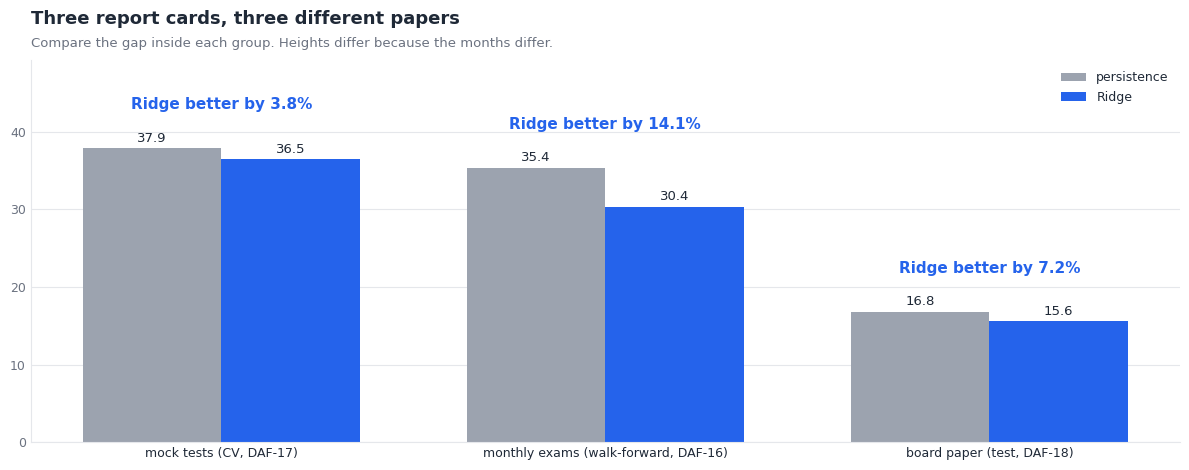

In [4]:
# Continues from Steps 1 to 3: project_root, config, scores.
# --- 1. Read the older report cards from the register, do not recompute them ----------------
log = pd.read_csv(project_root / "reports/experiments.csv").set_index("model")
walk_forward = log.loc[["daf16_ridge_walk_forward", "daf16_persistence_walk_forward"], ["mae", "recall_poor"]]

report_cards = pd.DataFrame({
    "Ridge MAE": [config["cv"]["mean_mae"], walk_forward.loc["daf16_ridge_walk_forward", "mae"], scores.loc["ridge", "MAE"]],
    "persistence MAE": [config["cv"]["persistence_mean_mae"], walk_forward.loc["daf16_persistence_walk_forward", "mae"],
                        scores.loc["persistence", "MAE"]],
    "Ridge recall": [log.loc["daf17_ridge_default_cv", "recall_poor"], walk_forward.loc["daf16_ridge_walk_forward", "recall_poor"],
                     scores.loc["ridge", "recall"]],
    "persistence recall": [log.loc["daf17_persistence_cv", "recall_poor"], walk_forward.loc["daf16_persistence_walk_forward", "recall_poor"],
                           scores.loc["persistence", "recall"]],
}, index=["mock tests (CV, DAF-17)", "monthly exams (walk-forward, DAF-16)", "board paper (test, DAF-18)"])
report_cards["gap"] = report_cards["persistence MAE"] - report_cards["Ridge MAE"]          # + = Ridge better
report_cards["gap %"] = 100 * report_cards["gap"] / report_cards["persistence MAE"]
display(report_cards.round(3))

# --- 2. Draw it: the gap is what matters, not the height --------------------------------------
fig, ax = plt.subplots(figsize=(12, 4.8))
x_pos = range(len(report_cards))
for offset, column, colour in ((-0.18, "persistence MAE", rs.BAR), (0.18, "Ridge MAE", rs.ACCENT)):
    bars = ax.bar([x + offset for x in x_pos], report_cards[column], 0.36, color=colour, label=column.replace(" MAE", ""))
    rs.label_bars(ax, bars, fmt="{:.1f}")
for x, (_, row) in zip(x_pos, report_cards.iterrows()):
    ax.text(x, max(row["Ridge MAE"], row["persistence MAE"]) + 5, f"Ridge better by {row['gap %']:.1f}%",
            ha="center", fontsize=11, fontweight="bold", color=rs.ACCENT if row["gap"] > 0 else rs.ALERT)
ax.set_xticks(list(x_pos), report_cards.index, fontsize=10.5)
ax.set_ylim(0, report_cards[["Ridge MAE", "persistence MAE"]].max().max() * 1.3)
rs.legend(ax, [("persistence", rs.BAR, "bar"), ("Ridge", rs.ACCENT, "bar")], loc="upper right")
rs.style_axis(ax, "Three report cards, three different papers", "Compare the gap inside each group. Heights differ because the months differ.")
plt.tight_layout(); plt.show()

### What this code does, line by line

| Line | What it does |
|---|---|
| `log = pd.read_csv(...).set_index("model")` | The register, with the model name as the row label so we can look rows up by name |
| `log.loc[[...ridge_walk_forward, ...persistence_walk_forward], ["mae", "recall_poor"]]` | Pick the two DAF-16 rows and the two columns we need |
| `config["cv"]["mean_mae"]` and `config["cv"]["persistence_mean_mae"]` | The DAF-17 mock-test marks, from the signed file |
| `log.loc["daf17_ridge_default_cv", "recall_poor"]` | The DAF-17 recall, from the register |
| `scores.loc["ridge", "MAE"]` | The board result from Step 3. Read, not computed again |
| `report_cards["gap"] = ...` | Persistence's mistake minus Ridge's. Positive means Ridge was better |
| `report_cards["gap %"] = 100 * gap / persistence MAE` | The same gap as a percentage. This is the number rule 1 talks about |
| `for offset, column, colour in (...)` | Two bars per group, shifted left and right by 0.18 |
| `rs.label_bars(ax, bars, fmt="{:.1f}")` | Write each bar's value on top (a helper from `recap_style.py`) |
| `ax.text(x, ..., f"Ridge better by {row['gap %']:.1f}%", ...)` | Above each group, the gap in words. Blue if Ridge was better, orange if worse |

### Read the result

| Report card | Ridge MAE | Persistence MAE | Ridge better by | Recall Ridge vs persistence |
|---|---:|---:|---:|---|
| Mock tests (CV, DAF-17) | 36.46 | 37.89 | 3.8% | 0.915 vs 0.906 |
| Monthly exams (walk-forward, DAF-16) | 30.38 | 35.35 | 14.1% | 0.908 vs 0.858 |
| **Board paper (test, DAF-18)** | **15.59** | **16.79** | **7.2%** | **0.706 vs 0.471** |

**All three point the same way:** Ridge is better than persistence on MAE and at least as good on recall, every time. So the win is not luck of one paper.

**The size of the win is not steady:** 3.8%, 14.1%, 7.2%. The walk-forward number is the only one above 10%, and it is the least independent: it covers October to August, including the six test months, and it refits the model every month, so it always knows the newest days. The board paper sits between the other two.

Sharma sir's reading: *"Three exams agree on who is better. They do not agree on by how much. So the honest sentence is: better, but not clearly 10% better."*

## Before Step 5

The marks are known and the other report cards agree in direction. Now the `judge` from Step 2 reads them.

# Step 5 — The verdict

## 🎬 How we got here

Step 2 wrote the pass marks. Step 3 produced the marks. Step 4 put them next to the older report cards.

---

**Sharma sir:** Now read the marks aloud, against the blackboard.

**Asha:** Sir, I will not read them myself. I will give them to the `judge` function from Step 2. It was written before the marks existed, and it was tested on the toy.

**Sharma sir:** Why not read them yourself?

**Asha:** Because if I read them, I may read them kindly.

**Sharma sir:** *(nods)* And what if it says NOT MET?

**Asha:** Then the verdict is NOT MET, and I write why, and what I would try next. I do not change the model.

---

## 😖 The problem

A verdict needs three things together: the numbers, the rule, and a plain answer. "Ridge MAE was X and persistence was Y" is not a verdict. Someone still has to decide what that means.

## 💡 The fix

Feed the Step 3 marks to `judge(...)`. Print one line per rule with the numbers and **MET** or **NOT MET**, then one line for the whole verdict.

Rule 1  MAE: Ridge 15.59 vs persistence 16.79  ->  7.2% lower (need 10%)  ->  NOT MET
Rule 2  recall on Poor days: Ridge 12 of 17 (0.706) vs persistence 8 of 17 (0.471)  ->  MET
VERDICT: NOT MET


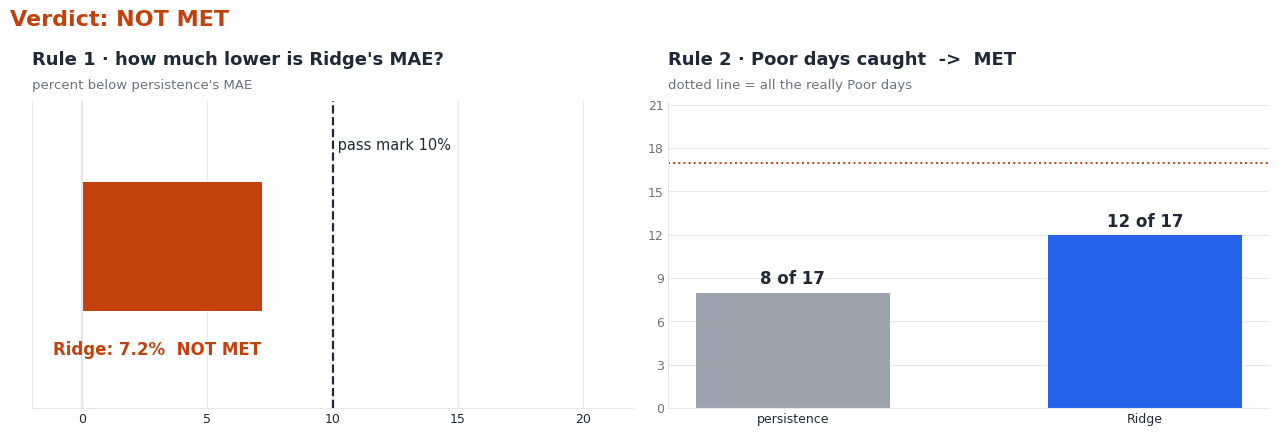

In [5]:
# Continues from Steps 2 and 3: scores, judge, MIN_MAE_IMPROVEMENT.
# --- 1. Apply the rules written in Step 2 ---------------------------------------------------
ridge_marks, persistence_marks = scores.loc["ridge"], scores.loc["persistence"]
improvement, rule_1, rule_2 = judge(ridge_marks, persistence_marks)
VERDICT = "MET" if rule_1 and rule_2 else "NOT MET"

def met(passed):
    return "MET" if passed else "NOT MET"

# --- 2. Say it in sentences, with the numbers ---------------------------------------------------
print(f"Rule 1  MAE: Ridge {ridge_marks['MAE']:.2f} vs persistence {persistence_marks['MAE']:.2f}"
      f"  ->  {improvement:.1%} lower (need {MIN_MAE_IMPROVEMENT:.0%})  ->  {met(rule_1)}")
print(f"Rule 2  recall on Poor days: Ridge {int(ridge_marks['caught'])} of {int(ridge_marks['Poor days'])} ({ridge_marks['recall']:.3f})"
      f" vs persistence {int(persistence_marks['caught'])} of {int(persistence_marks['Poor days'])} ({persistence_marks['recall']:.3f})"
      f"  ->  {met(rule_2)}")
print(f"VERDICT: {VERDICT}")

# --- 3. Draw it: each rule against its pass mark --------------------------------------------------
fig, (mae_ax, recall_ax) = plt.subplots(1, 2, figsize=(13, 4.4))
mae_ax.barh([0], [100 * improvement], color=rs.ACCENT if rule_1 else rs.ALERT, height=0.4)
mae_ax.axvline(100 * MIN_MAE_IMPROVEMENT, color=rs.INK, ls="--", lw=1.6)
mae_ax.text(100 * MIN_MAE_IMPROVEMENT, 0.3, f" pass mark {MIN_MAE_IMPROVEMENT:.0%}", fontsize=10.5, color=rs.INK)
mae_ax.text(100 * improvement, -0.32, f"Ridge: {improvement:.1%}  {met(rule_1)}", ha="right", va="center", fontsize=12, fontweight="bold",
            color=rs.ACCENT if rule_1 else rs.ALERT)
mae_ax.set_ylim(-0.5, 0.45)
mae_ax.set_xlim(min(0, 100 * improvement) - 2, max(100 * MIN_MAE_IMPROVEMENT, 100 * improvement) + 12)
mae_ax.set_yticks([]); mae_ax.axvline(0, color=rs.GRID)
rs.style_axis(mae_ax, "Rule 1 · how much lower is Ridge's MAE?", "percent below persistence's MAE", grid_axis="x")

recall_bars = recall_ax.bar(["persistence", "Ridge"], [persistence_marks["caught"], ridge_marks["caught"]],
                            color=[rs.BAR, rs.ACCENT if rule_2 else rs.ALERT], width=0.55)
for bar, marks in zip(recall_bars, (persistence_marks, ridge_marks)):
    recall_ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                   f"{int(marks['caught'])} of {int(marks['Poor days'])}", ha="center", va="bottom", fontsize=12, fontweight="bold", color=rs.INK)
recall_ax.axhline(ridge_marks["Poor days"], color=rs.ALERT, ls=":", lw=1.4)
recall_ax.set_ylim(0, ridge_marks["Poor days"] * 1.25)
rs.whole_numbers(recall_ax)
rs.style_axis(recall_ax, f"Rule 2 · Poor days caught  ->  {met(rule_2)}", "dotted line = all the really Poor days")
fig.suptitle(f"Verdict: {VERDICT}", x=0.02, ha="left", fontsize=16, fontweight="bold", color=rs.ACCENT if VERDICT == "MET" else rs.ALERT)
plt.tight_layout(); plt.show()

### What this code does, line by line

| Line | What it does |
|---|---|
| `ridge_marks, persistence_marks = scores.loc["ridge"], scores.loc["persistence"]` | Take each student's row of marks from Step 3 |
| `improvement, rule_1, rule_2 = judge(ridge_marks, persistence_marks)` | The function from Step 2 gives back three things; Python unpacks them into three names |
| `VERDICT = "MET" if rule_1 and rule_2 else "NOT MET"` | `A if condition else B`: MET only when **both** rules are true |
| `def met(passed): return "MET" if passed else "NOT MET"` | A tiny helper so each line can say MET or NOT MET |
| `f"{improvement:.1%}"` | Format a share like `0.034` as `3.4%` |
| `mae_ax.barh([0], [100 * improvement], ...)` | One horizontal bar: how far below persistence Ridge's MAE is, in percent. Blue if rule 1 passed, orange if not |
| `mae_ax.axvline(100 * MIN_MAE_IMPROVEMENT, ...)` | The pass mark as a dashed line at 10% |
| `recall_ax.bar(["persistence", "Ridge"], [... "caught" ...])` | How many Poor days each student caught |
| `recall_ax.axhline(ridge_marks["Poor days"], ...)` | A dotted line at the total number of Poor days, so you see how many were missed |
| `fig.suptitle(f"Verdict: {VERDICT}", ...)` | The answer, as the title of the picture |

### Read the result

| Rule | Pass mark | Result | |
|---|---|---|---|
| 1 · MAE | at least 10% lower than persistence | 15.59 vs 16.79 = **7.2% lower** | ❌ **NOT MET** |
| 2 · Recall on Poor days | not lower than persistence | **12 of 17** (0.706) vs 8 of 17 (0.471) | ✅ **MET** |

## Verdict: **NOT MET**

Said in one breath, the way Asha would say it to the principal:

> *"The model is better than my old method on every exam we ran. On the final test it caught 12 of the 17 smoggy days where my method caught 8, and its average mistake was 7% smaller. The target was 10%, so on the project's own rule it has **not** passed."*

Three things are true at the same time, and the report must say all three:

1. **It failed the rule.** 7.2% is below 10%. We do not round it up, and we do not lower the pass mark now.
2. **It is not useless.** On the safety rule it is clearly better: 4 more Poor days caught, 4 fewer children's mornings in smog, and one false alarm less.
3. **The rule was written before the test, so it stands.** If the 10% target is wrong for this problem, that is a new decision for the next version, written down as a decision record, not a change to today's verdict.

## Before Step 6

The verdict says *how much*. Step 6 asks *where*: which days did Ridge lose the most marks on?

# Step 6 — Open the answer sheet: the ten worst days

## 🎬 How we got here

Step 5 gave the verdict. It is an average over 130 days.

---

**Sharma sir:** The verdict is a single number. Asha, does a parent care about the average?

**Asha:** No sir. A parent cares about the one morning their child stood in smog.

**Sharma sir:** So open the answer sheet. Which questions did Ridge lose the most marks on?

**Asha:** I sort the 130 days by Ridge's mistake, biggest first, and take the top ten.

**Sharma sir:** And for each one?

**Asha:** The date, what really happened, what Ridge said, what persistence said. And a likely reason.

**Sharma sir:** Where will the reason come from? Your imagination?

**Asha:** From evidence, sir. The weather file from DAF-12 has the **real** weather of the next day: rain, wind, humidity. Ridge never saw it, because the model has no weather feature. If the air cleaned up and it rained 20 mm, that is a likely reason. I also look at the jump: how far tomorrow moved from today.

**Sharma sir:** And then?

**Asha:** If several worst days have the same reason, that is a **pattern**. A pattern goes into the model card as a known failure case.

---

## 😖 The problem

An average hides the dangerous days. And a "reason" written without evidence is a story we tell ourselves.

## 💡 The fix

1. Sort `test_result` (from Step 3, no new scoring) by the size of Ridge's mistake. Take the top ten.
2. Join the real weather of the forecast day from `data/interim/weather_features_archive.csv`. These columns are **evidence only**. They are not features, and nothing is refitted.
3. Add the jump (`actual − today_until_17`) and the direction of the mistake (too high or too low).
4. Read the table, then write one likely reason per day.
5. Count the patterns, and check how the mistakes spread over the months.

In [6]:
# Continues from Steps 1 and 3: project_root, test_result, POOR_LINE.
# --- 1. Real weather of the forecast day: evidence for the reasons, NOT a feature ---------------
weather = pd.read_csv(project_root / "data/interim/weather_features_archive.csv",
                      parse_dates=["prediction_date"], index_col="prediction_date")
weather.index = weather.index.normalize()

# --- 2. Sort the 130 test days by Ridge's mistake and keep the worst ten ----------------------
answer_sheet = test_result.join(weather)                                   # same row label: the evening of the forecast
answer_sheet["abs_error"] = answer_sheet["ridge_error"].abs()
answer_sheet["jump"] = answer_sheet["actual"] - answer_sheet["today_until_17"]   # how far tomorrow moved from today
worst = answer_sheet.nlargest(10, "abs_error").copy()

# --- 3. Make it readable ----------------------------------------------------------------------
worst.insert(0, "rank", range(1, 11))
worst["for day"] = (worst.index + pd.Timedelta(days=1)).strftime("%a %d %b")    # the day being forecast
worst["Ridge was"] = worst["ridge_error"].map(lambda e: "too high" if e > 0 else "too low")
worst["Poor?"] = (worst["actual"] >= POOR_LINE).map({True: "Poor", False: ""})
columns = ["rank", "for day", "today_until_17", "actual", "ridge", "persistence", "ridge_error", "Ridge was", "Poor?",
           "jump", "rain_tomorrow_total", "wind_tomorrow_mean", "humidity_tomorrow_max"]
display(worst[columns].round(1))

share = worst["abs_error"].sum() / answer_sheet["abs_error"].sum()
print(f"The worst 10 of 130 days carry {share:.0%} of Ridge's total mistake.")
print(f"Typical test day: rain {answer_sheet['rain_tomorrow_total'].median():.1f} mm, "
      f"wind {answer_sheet['wind_tomorrow_mean'].median():.1f} km/h, |jump| {answer_sheet['jump'].abs().median():.1f}")

,rank,for day,today_until_17,actual,ridge,persistence,ridge_error,Ridge was,Poor?,jump,rain_tomorrow_total,wind_tomorrow_mean,humidity_tomorrow_max
date,,,,,,,,,,,,,
2026-03-06,1,Sat 07 Mar,71.6,148.4,92.9,71.6,-55.5,too low,Poor,76.8,0.0,4.1,89.0
2026-05-28,2,Fri 29 May,83.3,24.1,79.2,83.3,55.2,too high,,-59.2,1.0,10.4,73.0
2026-03-15,3,Mon 16 Mar,70.4,43.1,93.6,70.4,50.5,too high,,-27.4,0.3,11.1,73.0
2026-04-18,4,Sun 19 Apr,73.5,120.5,76.3,73.5,-44.2,too low,Poor,47.0,0.0,8.0,43.0
2026-03-18,5,Thu 19 Mar,107.4,59.4,103.0,107.4,43.6,too high,,-48.0,3.4,8.0,88.0
2026-04-30,6,Fri 01 May,63.0,40.0,82.2,63.0,42.1,too high,,-23.0,0.0,8.4,71.0
2026-03-14,7,Sun 15 Mar,74.9,60.8,97.8,74.9,37.0,too high,,-14.2,2.6,11.3,89.0
2026-04-27,8,Tue 28 Apr,101.0,63.7,99.8,101.0,36.1,too high,,-37.3,0.0,7.5,40.0
2026-04-28,9,Wed 29 Apr,59.8,47.8,83.8,59.8,36.0,too high,,-12.0,0.0,5.8,58.0


The worst 10 of 130 days carry 21% of Ridge's total mistake.
Typical test day: rain 0.1 mm, wind 8.0 km/h, |jump| 12.5


### What this code does, line by line

**Part 1 — the weather evidence**

| Line | What it does |
|---|---|
| `pd.read_csv(".../weather_features_archive.csv", parse_dates=["prediction_date"], index_col="prediction_date")` | The real weather from DAF-12. Each row is labelled by the evening a forecast would be made, and holds **tomorrow's** rain, wind and humidity |
| `weather.index = weather.index.normalize()` | Midnight labels, so they match `test_result`'s labels |

**Part 2 — sort and pick**

| Line | What it does |
|---|---|
| `answer_sheet = test_result.join(weather)` | Put the weather next to each test day. `join` matches rows by their date label |
| `answer_sheet["abs_error"] = answer_sheet["ridge_error"].abs()` | The size of the mistake, ignoring the direction |
| `answer_sheet["jump"] = actual - today_until_17` | How much tomorrow differed from what Asha saw today. A big jump is a day persistence cannot see coming |
| `worst = answer_sheet.nlargest(10, "abs_error").copy()` | The ten rows with the biggest mistakes, biggest first. `.copy()` so that adding columns does not touch `answer_sheet` |

**Part 3 — readable columns**

| Line | What it does |
|---|---|
| `worst.insert(0, "rank", range(1, 11))` | A rank column at position 0: 1 to 10 |
| `(worst.index + pd.Timedelta(days=1)).strftime("%a %d %b")` | The row label is the evening of the forecast. The day being forecast is one day later. Written like `Sun 08 Mar` |
| `worst["ridge_error"].map(lambda e: "too high" if e > 0 else "too low")` | `.map` runs the small function on every value. Positive error = forecast too high |
| `(worst["actual"] >= POOR_LINE).map({True: "Poor", False: ""})` | Mark the days that were really Poor |
| `share = worst["abs_error"].sum() / answer_sheet["abs_error"].sum()` | How much of all of Ridge's mistakes comes from just these ten days |
| `answer_sheet[...].median()` | A normal test day, to compare the worst days with |

### Reading the table before writing reasons

Two directions of mistake show up, and they are not equally common:

- **8 of the 10 are "too high".** The air cleaned up, but Ridge kept forecasting a smoggy number. On most of them `mean_7` or `mean_14` was much higher than today's value: the averages still "remembered" a smoggy week.
- **2 of the 10 are "too low", and both were really Poor days.** The air jumped up overnight (+77 and +47) and nothing in today's numbers warned of it.

The weather columns help on some days (a windy day, a little rain, a calm and humid night) but not on all. Where the data has no cause, the reason says so. A guess written as a fact would be worse than "unknown".

The next cell writes one likely reason per day, **after** reading the table, and then checks two things that could explain the pattern: the model's average lean (bias), and how the mistakes change month by month. Both are read from `test_result`; nothing is scored again.

,rank,for day,actual,ridge,persistence,Ridge was,likely reason
date,,,,,,,
2026-03-06,1,Sat 07 Mar,148.4,92.9,71.6,too low,"Jumped from 72 to 148 overnight. The next day was calm (wind 4 km/h) and humid (89%), so smoke stayed trapped near the ground. Today's numbers gave no warning, and Ridge has no weather feature"
2026-05-28,2,Fri 29 May,24.1,79.2,83.3,too high,"Fell from 83 to 24. A windier day than usual (10.4 km/h) with a little rain cleared the air. The last 3 days averaged 82, which held Ridge at 79"
2026-03-15,3,Mon 16 Mar,43.1,93.6,70.4,too high,Fell to 43 after a smoggy week. mean_7 (106) and mean_14 (100) kept Ridge near 94. Wind 11 km/h cleared the air
2026-04-18,4,Sun 19 Apr,120.5,76.3,73.5,too low,Rose from 74 to 121 on a dry day with normal wind. Our data shows no cause: probably a local source such as dust or burning. A missed Poor day
2026-03-18,5,Thu 19 Mar,59.4,103.0,107.4,too high,"Today was 107, tomorrow 59. 3.4 mm of rain (a normal test day has 0.1 mm) washed the air. Ridge followed today's high value"
2026-04-30,6,Fri 01 May,40.0,82.2,63.0,too high,"Today was 63, but mean_14 (88) remembered the smoggy fortnight and pulled Ridge up to 82. Real: 40"
2026-03-14,7,Sun 15 Mar,60.8,97.8,74.9,too high,"After a week averaging 116, the air fell to 61, with wind 11 km/h and 2.6 mm of rain. Ridge stayed near 98"
2026-04-27,8,Tue 28 Apr,63.7,99.8,101.0,too high,"Today 101, tomorrow 64, on a dry day with normal wind. No clear cause in our data. Ridge, like persistence, followed today's value"
2026-04-28,9,Wed 29 Apr,47.8,83.8,59.8,too high,"Today was 60, but the last 3 days averaged 100, so Ridge said 84. Real: 48"


pattern
air cleaned up, Ridge stayed high    8
sudden spike, no warning             2

average lean on the test days: Ridge +8.2, persistence -1.1 µg/m³ (+ = too high)
average target: train days 118.5, test days 58.1
Ridge weights per µg/m³: {'pm25_until_17': 0.43, 'mean_3': 0.03, 'mean_7': 0.11, 'mean_14': 0.4}


,days,poor_days,actual_mean,ridge_mae,persistence_mae,ridge_lean,winner
date,,,,,,,
2026-03,28,9,83.5,19.8,22.7,10.0,Ridge
2026-04,29,7,70.3,19.1,21.6,7.1,Ridge
2026-05,26,1,54.8,14.2,14.8,7.6,Ridge
2026-06,18,0,42.1,14.8,16.6,10.5,Ridge
2026-07,22,0,32.2,11.0,9.2,8.2,persistence
2026-08,7,0,41.3,5.8,5.0,2.2,persistence


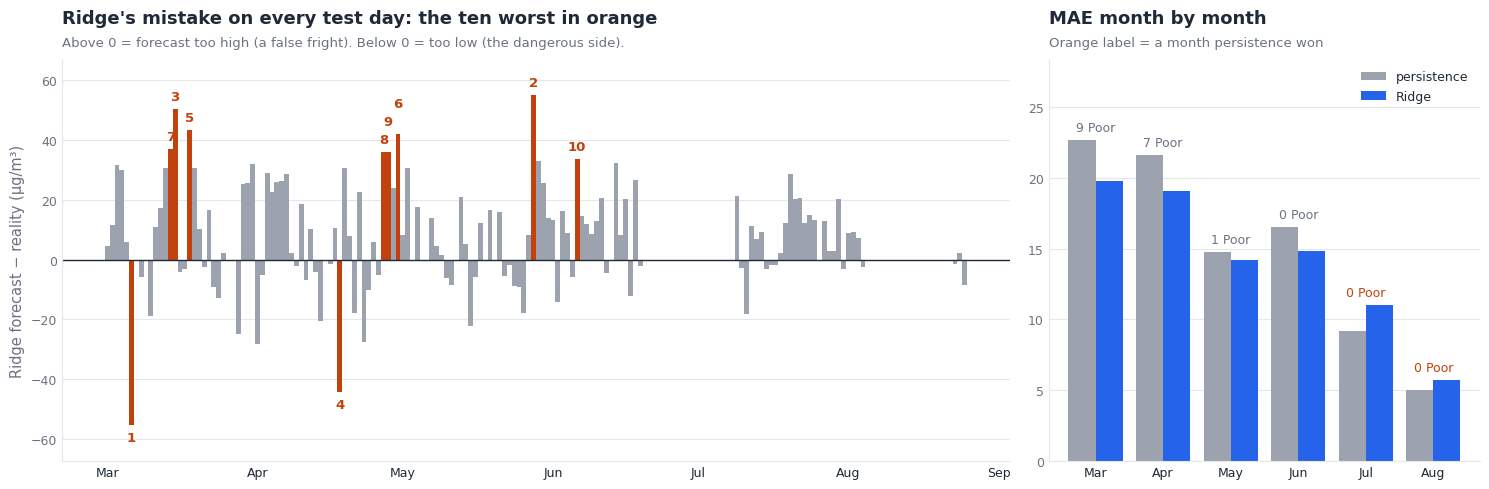

In [7]:
# Continues from Steps 3 and 6: test_result, answer_sheet, worst, train, model, feature_names, POOR_LINE.
# --- 1. One likely reason per worst day, written after reading the table above ------------------
HIGH, SPIKE = "air cleaned up, Ridge stayed high", "sudden spike, no warning"
reasons = {
    "2026-03-06": (SPIKE, "Jumped from 72 to 148 overnight. The next day was calm (wind 4 km/h) and humid (89%), so smoke stayed "
                          "trapped near the ground. Today's numbers gave no warning, and Ridge has no weather feature"),
    "2026-05-28": (HIGH,  "Fell from 83 to 24. A windier day than usual (10.4 km/h) with a little rain cleared the air. "
                          "The last 3 days averaged 82, which held Ridge at 79"),
    "2026-03-15": (HIGH,  "Fell to 43 after a smoggy week. mean_7 (106) and mean_14 (100) kept Ridge near 94. Wind 11 km/h cleared the air"),
    "2026-04-18": (SPIKE, "Rose from 74 to 121 on a dry day with normal wind. Our data shows no cause: probably a local source "
                          "such as dust or burning. A missed Poor day"),
    "2026-03-18": (HIGH,  "Today was 107, tomorrow 59. 3.4 mm of rain (a normal test day has 0.1 mm) washed the air. "
                          "Ridge followed today's high value"),
    "2026-04-30": (HIGH,  "Today was 63, but mean_14 (88) remembered the smoggy fortnight and pulled Ridge up to 82. Real: 40"),
    "2026-03-14": (HIGH,  "After a week averaging 116, the air fell to 61, with wind 11 km/h and 2.6 mm of rain. Ridge stayed near 98"),
    "2026-04-27": (HIGH,  "Today 101, tomorrow 64, on a dry day with normal wind. No clear cause in our data. "
                          "Ridge, like persistence, followed today's value"),
    "2026-04-28": (HIGH,  "Today was 60, but the last 3 days averaged 100, so Ridge said 84. Real: 48"),
    "2026-06-06": (HIGH,  "Summer day: fell from 68 to 32. Ridge sat above today's value, as it did on most summer days"),
}
assert set(reasons) == {str(day.date()) for day in worst.index}, "every worst day needs exactly one reason"
worst["pattern"] = [reasons[str(day.date())][0] for day in worst.index]
worst["likely reason"] = [reasons[str(day.date())][1] for day in worst.index]
with pd.option_context("display.max_colwidth", None):
    display(worst[["rank", "for day", "actual", "ridge", "persistence", "Ridge was", "likely reason"]].round(1))
print(worst["pattern"].value_counts().to_string())

# --- 2. The lean: on average, is Ridge too high or too low? --------------------------------------
bias = test_result[["ridge_error", "persistence_error"]].mean()
print(f"\naverage lean on the test days: Ridge {bias['ridge_error']:+.1f}, persistence {bias['persistence_error']:+.1f} µg/m³ (+ = too high)")
print(f"average target: train days {train[TARGET].mean():.1f}, test days {test_result['actual'].mean():.1f}")
weights = dict(zip(feature_names, model[-1].coef_ / model[0].scale_))          # weight per 1 µg/m³ of each feature
print("Ridge weights per µg/m³:", {name: round(float(w), 2) for name, w in weights.items()})

# --- 3. Month by month: where does Ridge win, where does it lose? ---------------------------------
by_month = test_result.groupby(test_result.index.to_period("M")).agg(
    days=("actual", "size"),
    poor_days=("actual", lambda a: int((a >= POOR_LINE).sum())),
    actual_mean=("actual", "mean"),
    ridge_mae=("ridge_error", lambda e: e.abs().mean()),
    persistence_mae=("persistence_error", lambda e: e.abs().mean()),
    ridge_lean=("ridge_error", "mean"),
)
by_month["winner"] = (by_month["ridge_mae"] < by_month["persistence_mae"]).map({True: "Ridge", False: "persistence"})
display(by_month.round(1))

# --- 4. Draw it: every test day's mistake with the worst ten marked, and the months ---------------
fig, (day_ax, month_ax) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2.2, 1]})
is_worst = test_result.index.isin(worst.index)
day_ax.bar(test_result.index, test_result["ridge_error"], width=1.0,
           color=[rs.ALERT if w else rs.BAR for w in is_worst])
last_label = (None, None)                                          # (date, height) of the previous label
for day, row in worst.sort_index().iterrows():
    sign = 1 if row["ridge_error"] > 0 else -1
    y = row["ridge_error"] + 2 * sign
    if last_label[0] is not None and (day - last_label[0]).days <= 2 and abs(y - last_label[1]) < 6:
        y = last_label[1] + 6 * sign                                # neighbour too close: lift this label
    day_ax.text(day, y, str(row["rank"]), ha="center", va="bottom" if sign > 0 else "top", fontsize=9.5, fontweight="bold", color=rs.ALERT)
    last_label = (day, y)
day_ax.axhline(0, color=rs.INK, lw=1)
day_ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
day_ax.set_ylim(test_result["ridge_error"].min() - 12, test_result["ridge_error"].max() + 12)
day_ax.set_ylabel("Ridge forecast − reality (µg/m³)", fontsize=10.5, color=rs.MUTED)
rs.style_axis(day_ax, "Ridge's mistake on every test day: the ten worst in orange",
              "Above 0 = forecast too high (a false fright). Below 0 = too low (the dangerous side).")

months = [p.strftime("%b") for p in by_month.index]
x_pos = range(len(months))
month_ax.bar([x - 0.2 for x in x_pos], by_month["persistence_mae"], 0.4, color=rs.BAR)
month_ax.bar([x + 0.2 for x in x_pos], by_month["ridge_mae"], 0.4, color=rs.ACCENT)
for x, (_, row) in zip(x_pos, by_month.iterrows()):
    month_ax.text(x, max(row["ridge_mae"], row["persistence_mae"]) + 0.6, f"{row['poor_days']} Poor",
                  ha="center", fontsize=9, color=rs.ALERT if row["winner"] == "persistence" else rs.MUTED)
month_ax.set_xticks(list(x_pos), months)
month_ax.set_ylim(0, by_month[["ridge_mae", "persistence_mae"]].max().max() * 1.25)
rs.legend(month_ax, [("persistence", rs.BAR, "bar"), ("Ridge", rs.ACCENT, "bar")], loc="upper right")
rs.style_axis(month_ax, "MAE month by month", "Orange label = a month persistence won")
plt.tight_layout(); plt.show()

### What this code does, line by line

**Part 1 — the reasons**

| Line | What it does |
|---|---|
| `HIGH, SPIKE = "...", "..."` | The two pattern names, written once so the spelling is the same everywhere |
| `reasons = {"2026-03-06": (SPIKE, "..."), ...}` | A dictionary: the evening of the forecast → (pattern, reason). Written by hand **after** reading the table, from the numbers in it |
| `assert set(reasons) == {str(day.date()) for day in worst.index}` | The set of dates with a reason must be exactly the set of worst dates. No day forgotten, no extra day |
| `worst["pattern"] = [reasons[str(day.date())][0] for day in worst.index]` | For each worst day, take element `[0]` (the pattern) of its tuple |
| `pd.option_context("display.max_colwidth", None)` | Inside this `with` block only, show long text in full instead of cutting it with `...` |
| `worst["pattern"].value_counts()` | How many days have each pattern |

**Part 2 — the lean**

| Line | What it does |
|---|---|
| `test_result[["ridge_error", "persistence_error"]].mean()` | The average error **with** its sign. If plus and minus mistakes cancel, this is near 0. If it is clearly above 0, the forecast leans too high |
| `train[TARGET].mean()` and `test_result["actual"].mean()` | How smoggy an average day was in the study year and in the test months |
| `model[-1].coef_ / model[0].scale_` | `model[-1]` is the Ridge step, `model[0]` the scaler. Ridge's weights are for scaled features; dividing by each feature's spread gives the weight per 1 µg/m³, which is easier to read |

**Part 3 — month by month**

| Line | What it does |
|---|---|
| `test_result.groupby(test_result.index.to_period("M"))` | Put the days into groups by month: `2026-03`, `2026-04`, ... |
| `.agg(days=("actual", "size"), ...)` | For each month, make one row. Each `name=(column, function)` pair builds one column: count of days, Poor days, average real value, both MAEs, Ridge's lean |
| `lambda e: e.abs().mean()` | A small function written in place: the MAE of that month's errors |
| `by_month["winner"] = (...).map({True: "Ridge", False: "persistence"})` | Which student had the smaller MAE that month |

**Part 4 — the picture**

| Line | What it does |
|---|---|
| `is_worst = test_result.index.isin(worst.index)` | True for the ten worst days |
| `day_ax.bar(test_result.index, test_result["ridge_error"], ...)` | One thin bar per day: up = too high, down = too low. Orange for the ten worst |
| `for day, row in worst.sort_index().iterrows():` | Go through the ten worst days in date order |
| `if ... (day - last_label[0]).days <= 2 and abs(y - last_label[1]) < 6:` | Two worst days next to each other with bars of almost the same height (27 and 28 April) would print their ranks on top of each other. Then lift the second label a little |
| `day_ax.text(day, y, str(row["rank"]), ...)` | Write the rank (1 to 10) at the tip of each orange bar |
| `month_ax.bar([x - 0.2 ...], ...)` and `[x + 0.2 ...]` | Two bars per month, side by side |
| `f"{row['poor_days']} Poor"` | The number of Poor days above each month, in orange where persistence won |

### Read the result

**The ten worst days, with reasons**

| Rank | For day | Real | Ridge | Persistence | Ridge was | Likely reason |
|---:|---|---:|---:|---:|---|---|
| 1 | Sat 07 Mar | 148.4 | 92.9 | 71.6 | too low | Sudden spike. Calm (4 km/h) and humid (89%) night trapped the smoke. No warning in today's numbers |
| 2 | Fri 29 May | 24.1 | 79.2 | 83.3 | too high | Windy day with a little rain cleared the air. The 3-day average held Ridge up |
| 3 | Mon 16 Mar | 43.1 | 93.6 | 70.4 | too high | End of a smoggy week. `mean_7` 106 and `mean_14` 100 kept Ridge high |
| 4 | Sun 19 Apr | 120.5 | 76.3 | 73.5 | too low | Sudden spike on a dry, normal day. Cause unknown (dust or burning?). A missed Poor day |
| 5 | Thu 19 Mar | 59.4 | 103.0 | 107.4 | too high | 3.4 mm of rain washed the air |
| 6 | Fri 01 May | 40.0 | 82.2 | 63.0 | too high | `mean_14` 88 remembered the smoggy fortnight |
| 7 | Sun 15 Mar | 60.8 | 97.8 | 74.9 | too high | After a week averaging 116, wind and rain cleared it |
| 8 | Tue 28 Apr | 63.7 | 99.8 | 101.0 | too high | Fell 37 with no clear cause in our data |
| 9 | Wed 29 Apr | 47.8 | 83.8 | 59.8 | too high | The 3-day average (100) pulled Ridge up |
| 10 | Sun 07 Jun | 32.3 | 65.9 | 68.1 | too high | Summer: Ridge sat above today's value, as on most summer days |

These ten days (8% of the test) carry **21%** of Ridge's total mistake.

**Three patterns, and the evidence for each**

| Pattern | Evidence | What it means for Asha |
|---|---|---|
| **Slow to see the air clean up** (8 of 10) | `mean_14` has the biggest weight after today's value (0.40 per µg/m³, against 0.43 for `pm25_until_17`). After a smoggy week, the averages stay high for days | After a smog spell ends, the forecast stays high for a few days. These are false frights, not dangers |
| **Blind to sudden spikes** (2 of 10, both Poor days) | +77 and +47 overnight, with nothing in today's numbers. Ridge has no weather feature, and no feature about fires or dust | A sudden smoggy morning can come with no warning. This is the dangerous side |
| **Leans high in clean months** | Average lean **+8.2** µg/m³ for Ridge (persistence −1.1). The study year averaged **118.5**, the test months **58.1**. Ridge learned on a year with a full smog winter | In summer and monsoon the number is a bit too high. Persistence **won July and August** |

**Month by month:** Ridge won March to June, the months with Poor days. Persistence won July and August, the cleanest months, where "tomorrow = today" is very hard to beat and Ridge's upward lean costs it.

**What would we try next (for a version 2, not today):** the two biggest patterns both point to missing information, not to wrong settings. Tomorrow's **weather forecast** (wind, rain, humidity), which DAF-13 already has as a feature family, speaks directly to "the air cleaned up" and "calm night trapped the smoke". A **season or month** feature could fix the summer lean. And a second smog winter of data would give Ridge more than one winter to learn from. None of these is tried here: that would be using the test days to choose the next model.

## Before Step 7

The answers are known and explained. Now the model must survive outside this notebook: a file, a fresh Python, the same forecast.

# Step 7 — Write the recipe in the register: save, close, load again

## 🎬 How we got here

Steps 3 to 6 used the model **inside** this notebook. When the notebook closes, the fitted model disappears from memory.

---

**Sharma sir:** Asha, next month the service in DAF-20 must make the forecast every evening at 6. Will it run your notebook?

**Asha:** No sir. It will load a file.

**Sharma sir:** What must be in that file?

**Asha:** The fitted model, of course. And the four feature names, in the right order, because Ridge only knows "the first number, the second number". If someone sends `mean_14` first, it gives a wrong forecast with no error. And the training dates, so that anyone can see which year it learned from.

**Sharma sir:** And how do you know the file works?

**Asha:** I open a **new** Python, where nothing from this notebook exists. It loads the file, gets the features of one test day, and makes a forecast. That forecast must be exactly the one from Step 3.

**Sharma sir:** Is that opening the envelope a second time?

**Asha:** No sir. It does not compute a score, and nothing is changed. It only checks that the file and the notebook are the same student.

---

## 😖 The problem

| What can go wrong | What it looks like |
|---|---|
| The file holds only the model | The service guesses the feature order, or uses a different list |
| "It loads" is tested in the same notebook | The notebook's memory hides problems (a missing import, a different variable). A fresh process has nothing to lean on |
| A different library version | `joblib` files made with one scikit-learn version may not load in another. We write the version in the file |

## 💡 The fix

`joblib.dump` a small dictionary: the fitted model plus everything needed to use it (feature list, training dates and rows, the fingerprint, the Poor line, the version). Then start a separate Python process with `subprocess`, load the file there, and compare its forecast for one test day with Step 3's.

`models/*.joblib` is ignored by git (only `final_config.json` is tracked), so the model file stays on this computer. Anyone can rebuild it from the config and this notebook.

In [8]:
# Continues from Steps 1 to 3: project_root, model, feature_names, train, test, test_result, fingerprint, POOR_LINE.
import subprocess
import sys
from datetime import date

import joblib
import sklearn

# --- 1. One file: the fitted model and everything needed to use it correctly ----------------------
model_path = project_root / "models/pm25_station17_v1.joblib"
bundle = {
    "model": model,                                          # the fitted pipeline from Step 3
    "features": feature_names,                               # the order matters
    "target": "next day 24-hour mean PM2.5, µg/m³, IST, R K Puram (OpenAQ location 17)",
    "poor_line": POOR_LINE,
    "train_rows": len(train),
    "train_first_date": str(train.index.min().date()),
    "train_last_date": str(train.index.max().date()),
    "train_target_sha256": fingerprint,
    "recipe": "models/final_config.json",
    "ticket": "DAF-18",
    "saved_on": str(date.today()),
    "sklearn_version": sklearn.__version__,
}
joblib.dump(bundle, model_path)
print(f"saved {model_path.relative_to(project_root)}  ({model_path.stat().st_size / 1024:.1f} KB)")

# --- 2. One test day to check with, and the answer Step 3 gave for it -------------------------------
check_day = test.index[0]
check_features = {name: float(test.loc[check_day, name]) for name in feature_names}
expected = float(test_result.loc[check_day, "ridge"])

# --- 3. A brand-new Python process: nothing from this notebook exists in it -------------------------
fresh_session = """
import json, sys
import joblib
import pandas as pd

bundle = joblib.load(sys.argv[1])
row = pd.DataFrame([json.loads(sys.argv[2])])[bundle["features"]]
print(json.dumps({"forecast": float(bundle["model"].predict(row)[0]),
                  "features": bundle["features"],
                  "trained_on": [bundle["train_first_date"], bundle["train_last_date"]]}))
"""
finished = subprocess.run([sys.executable, "-c", fresh_session, str(model_path), json.dumps(check_features)],
                          capture_output=True, text=True, check=True)
reloaded = json.loads(finished.stdout)

# --- 4. Same student? --------------------------------------------------------------------------------
assert abs(reloaded["forecast"] - expected) < 1e-9, "the saved model does not reproduce Step 3's forecast"
assert reloaded["features"] == feature_names, "the saved feature list is different"
print(f"check day       : forecast made on {check_day.date()} for {(check_day + pd.Timedelta(days=1)).date()}")
print(f"features sent   : { {k: round(v, 1) for k, v in check_features.items()} }")
print(f"Step 3 forecast : {expected:.6f}")
print(f"fresh session   : {reloaded['forecast']:.6f}   trained on {reloaded['trained_on'][0]} to {reloaded['trained_on'][1]}")
print("Same forecast in a new Python process: the file is the model we tested.")

saved models/pm25_station17_v1.joblib  (1.9 KB)


check day       : forecast made on 2026-03-01 for 2026-03-02
features sent   : {'pm25_until_17': 83.6, 'mean_3': 104.9, 'mean_7': 112.8, 'mean_14': 111.1}
Step 3 forecast : 104.646922
fresh session   : 104.646922   trained on 2025-03-17 to 2026-02-28
Same forecast in a new Python process: the file is the model we tested.


### What this code does, line by line

**Part 1 — save**

| Line | What it does |
|---|---|
| `import subprocess`, `import sys` | `subprocess` starts another program from Python. `sys.executable` is the path of the Python running this notebook, so the new process uses the same environment |
| `import joblib` | The usual tool for saving scikit-learn models. It is good at the large number arrays inside a model |
| `model_path = project_root / "models/pm25_station17_v1.joblib"` | The name the ticket asks for. `v1` because a version 2 will come |
| `bundle = {...}` | A dictionary, not only the model. The service will read `bundle["features"]` to put the columns in the right order |
| `"train_target_sha256": fingerprint` | The fingerprint from Step 1, so the file can be traced back to the exact training data |
| `joblib.dump(bundle, model_path)` | Write the whole dictionary into one file |
| `model_path.stat().st_size / 1024` | The file size in KB. A Ridge model is tiny: four weights, an intercept, and the scaler's averages and spreads |

**Part 2 — what to check**

| Line | What it does |
|---|---|
| `check_day = test.index[0]` | The first test day, 1 March 2026 |
| `{name: float(test.loc[check_day, name]) for name in feature_names}` | Its four features as plain Python numbers. `float(...)` because JSON cannot store numpy numbers |
| `expected = float(test_result.loc[check_day, "ridge"])` | The forecast Step 3 made for that day |

**Part 3 — a fresh Python**

| Line | What it does |
|---|---|
| `fresh_session = """..."""` | A tiny program, written as text. It will run in a new process |
| `joblib.load(sys.argv[1])` | In the new process: load the file. `sys.argv[1]` is the first thing we pass in, the file path |
| `pd.DataFrame([json.loads(sys.argv[2])])[bundle["features"]]` | Turn the features we passed (as JSON text) into a one-row table, with the columns put in the order the **file** says |
| `print(json.dumps({...}))` | Send the answer back as JSON text on the screen output |
| `subprocess.run([sys.executable, "-c", fresh_session, path, features], capture_output=True, text=True, check=True)` | Run `python -c "<program>" <path> <features>`. `capture_output=True` collects what it prints, `text=True` gives it as a string, `check=True` stops with an error if the program fails |
| `reloaded = json.loads(finished.stdout)` | Read the new process's answer back into a dictionary |

**Part 4 — compare**

| Line | What it does |
|---|---|
| `assert abs(reloaded["forecast"] - expected) < 1e-9` | The two forecasts must be the same to 9 decimal places |
| `assert reloaded["features"] == feature_names` | The feature list survived the trip |

### Read the result

The file `models/pm25_station17_v1.joblib` was saved and loaded in a separate Python process. For the first test day (forecast made on 1 March 2026), the fresh process gave **exactly** the same forecast as Step 3, and the same feature list and training dates came back with it.

That is acceptance criterion 4: *the model file loads in a fresh Python session and reproduces one test prediction.* DAF-19 and DAF-20 can now build the live service on this file.

## Before Step 8

The model is saved. The last thing it needs is the paper inside the medicine box.

# Step 8 — The model card: the paper inside the medicine box

## 🎬 How we got here

---

**Sharma sir:** Asha, one year from now a new teacher joins. She finds `pm25_station17_v1.joblib`. What does she know?

**Asha:** Nothing, sir. It is a file of numbers.

**Sharma sir:** Then write her one page. What goes on it?

**Asha:** What it predicts and for whom. Which data it learned from: station 17, the dates, and why only one station (D-005). The four features. The marks: the test result, and the other two report cards next to it. The Poor line, 91. The days it fails on, from Step 6. And where it must **not** be used.

**Sharma sir:** Which part will she read most carefully?

**Asha:** The last two. Where it fails, and where not to use it. A good number with no warning is how people get hurt.

**Sharma sir:** And the verdict?

**Asha:** NOT MET, written at the top. Not hidden at the bottom.

---

## 😖 The problem

Everything we learned is spread over this notebook, two decision records, a config file and a log. Nobody will read all of that before using the model. And a hand-written card can easily carry a number that does not match the notebook.

## 💡 The fix

`docs/model_card.md` holds the seven sections the ticket asks for, in plain English. The cell below does not write the card; it **checks** it: every section must be there, and the key numbers in the card must be the numbers this notebook computed. If someone edits the card later and a number drifts, this cell fails.

| Section | What it answers |
|---|---|
| Purpose | what it predicts, for whom, at what time |
| Data | station 17, dates, D-005, the 251 / 130 split |
| Features | the four inputs and their weights |
| Metrics | test result, verdict, the other report cards |
| Decision threshold | 91 µg/m³, how a number becomes "stay indoors" |
| Known failure cases | the three patterns from Step 6 |
| Do not use for | the limits |

In [9]:
# Continues from Steps 3 to 7: project_root, scores, improvement, VERDICT, report_cards, model_path.
card_path = project_root / "docs/model_card.md"
card = card_path.read_text()

# --- 1. Every section the ticket asks for -----------------------------------------------------------
required_sections = ["## Purpose", "## Data", "## Features", "## Metrics", "## Decision threshold",
                     "## Known failure cases", "## Do not use for"]
missing = [section for section in required_sections if section not in card]
assert not missing, f"model card is missing: {missing}"

# --- 2. The numbers in the card must be this notebook's numbers --------------------------------------
ridge_marks, persistence_marks = scores.loc["ridge"], scores.loc["persistence"]
must_appear = {
    "Ridge test MAE": f"{ridge_marks['MAE']:.2f}",
    "persistence test MAE": f"{persistence_marks['MAE']:.2f}",
    "improvement": f"{improvement:.1%}",
    "Ridge caught": f"{int(ridge_marks['caught'])} of {int(ridge_marks['Poor days'])}",
    "persistence caught": f"{int(persistence_marks['caught'])} of {int(persistence_marks['Poor days'])}",
    "verdict": f"**{VERDICT}**",
    "CV improvement": f"{report_cards.loc['mock tests (CV, DAF-17)', 'gap %']:.1f}%",
    "walk-forward improvement": f"{report_cards.loc['monthly exams (walk-forward, DAF-16)', 'gap %']:.1f}%",
    "model file": model_path.name,
}
wrong = {name: text for name, text in must_appear.items() if text not in card}
assert not wrong, f"the card does not match the notebook: {wrong}"

print(f"{card_path.relative_to(project_root)}: {len(required_sections)} sections present, "
      f"{len(must_appear)} numbers match the notebook")
for name, text in must_appear.items():
    print(f"  {name:<26} {text}")

docs/model_card.md: 7 sections present, 9 numbers match the notebook
  Ridge test MAE             15.59
  persistence test MAE       16.79
  improvement                7.2%
  Ridge caught               12 of 17
  persistence caught         8 of 17
  verdict                    **NOT MET**
  CV improvement             3.8%
  walk-forward improvement   14.1%
  model file                 pm25_station17_v1.joblib


### What this code does, line by line

| Line | What it does |
|---|---|
| `card = card_path.read_text()` | The whole card as one string |
| `required_sections = [...]` | The seven headings from step 5 of the ticket, exactly as they are written in the card |
| `missing = [section for section in required_sections if section not in card]` | Keep the headings that are **not** found. `in` on a string asks "does this text appear anywhere in it?" |
| `assert not missing, ...` | An empty list counts as False, so `not missing` is True only when nothing is missing |
| `must_appear = {...}` | Each key number, formatted exactly as the card writes it: two decimals for MAE, `12 of 17` for counts, `7.2%` for the gap |
| `f"{improvement:.1%}"` | `0.0716` becomes `7.2%` |
| `wrong = {name: text for ... if text not in card}` | Every number that cannot be found in the card |
| `assert not wrong, ...` | Stop if any number in the card disagrees with the notebook |

### Read the result

All seven sections are in `docs/model_card.md`, and the nine key numbers in the card are the numbers this notebook computed. Open the card next to this notebook: it is one page, with the verdict at the top and the two red-flag sections (*Known failure cases*, *Do not use for*) at the end.

That is acceptance criterion 5.

## Before Step 9

Last step: one line per student in the register, so the result is never lost.

# Step 9 — Write the board result in the register

## 🎬 How we got here

---

**Sharma sir:** The register, `experiments.csv`. How many kinds of exam are in it now?

**Asha:** Three, sir. Single cut (DAF-06 to DAF-15), walk-forward (DAF-16), cross-validation (DAF-17). Now a fourth: the final test.

**Sharma sir:** DAF-06 already has a persistence row on the test days. MAE 15.7. You got 16.8. Which is right?

**Asha:** Both, sir, for their own paper. DAF-06 scored 161 days. Here only 130 days have all four features, because `mean_14` needs two weeks of history and some days are missing. Different paper, so the note must say "130 rows" and "not comparable with DAF-06".

**Sharma sir:** And if you run the notebook again tomorrow?

**Asha:** The DAF-18 rows are replaced, not added twice. And the other tickets' rows are checked to be exactly as before.

---

## 💡 What this step does

Two rows, `daf18_ridge_test` and `daf18_persistence_test`, each with its MAE, recall and a note that says: final test, scored once, 130 rows, the counts, and the verdict. The same safe-write pattern as DAF-17 Step 8.

In [10]:
# Continues from Steps 1 to 7: project_root, train, test, scores, improvement, VERDICT, feature_names, model_path.
log_path = project_root / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]

# --- 1. Two rows, read from the one test run of Step 3 ------------------------------------------------
common_note = (f"FINAL TEST, scored once: fit on {len(train)} train rows ({train.index.min().date()} to {train.index.max().date()}), "
               f"scored on {len(test)} test rows ({test.index.min().date()} to {test.index.max().date()}), "
               f"{int(scores.loc['ridge', 'Poor days'])} Poor (warn at {POOR_LINE})")
descriptions = {
    "ridge": f"StandardScaler+Ridge(alpha=1.0, solver=lsqr) from models/final_config.json, saved as models/{model_path.name}",
    "persistence": "persistence, no fitting, forecast = pm25_until_17",
}
new_rows = pd.DataFrame([
    {
        "ticket": "DAF-18",
        "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
        "model": f"daf18_{name}_test",
        "features": ", ".join(feature_names),
        "mae": round(float(scores.loc[name, "MAE"]), 3),
        "recall_poor": round(float(scores.loc[name, "recall"]), 3),
        "notes": (f"{common_note}; {descriptions[name]}; caught {int(scores.loc[name, 'caught'])}, missed {int(scores.loc[name, 'missed'])}, "
                  f"false alarms {int(scores.loc[name, 'false alarms'])}; verdict {VERDICT}: Ridge MAE {improvement:.1%} lower than persistence "
                  f"(need 10%), recall not lower; not comparable with DAF-06 (161 rows), walk-forward or cross-validation rows"),
    }
    for name in ("ridge", "persistence")
], columns=log_columns)

# --- 2. Write them, safe to re-run --------------------------------------------------------------------
experiment_log = pd.read_csv(log_path)
other_rows = experiment_log.loc[experiment_log["ticket"] != "DAF-18"].reset_index(drop=True)
pd.concat([other_rows, new_rows], ignore_index=True)[log_columns].to_csv(log_path, index=False)

# --- 3. Read it back and check ------------------------------------------------------------------------
saved = pd.read_csv(log_path)
daf18 = saved.loc[saved["ticket"] == "DAF-18"].set_index("model")
assert len(daf18) == 2, "expected exactly two DAF-18 rows"
assert daf18["notes"].str.contains("FINAL TEST, scored once").all(), "every row must say it is the final test"
assert saved.loc[saved["ticket"] != "DAF-18"].reset_index(drop=True).equals(other_rows), "rows from other tickets changed"
print(f"Wrote 2 DAF-18 rows to {log_path.relative_to(project_root)}; the other {len(other_rows)} rows are untouched")
display(daf18[["mae", "recall_poor"]])
print("Note on the Ridge row:")
print(daf18.loc["daf18_ridge_test", "notes"])

Wrote 2 DAF-18 rows to reports/experiments.csv; the other 24 rows are untouched


,mae,recall_poor
model,,
daf18_ridge_test,15.588,0.706
daf18_persistence_test,16.791,0.471


Note on the Ridge row:
FINAL TEST, scored once: fit on 251 train rows (2025-03-17 to 2026-02-28), scored on 130 test rows (2026-03-01 to 2026-08-25), 17 Poor (warn at 91); StandardScaler+Ridge(alpha=1.0, solver=lsqr) from models/final_config.json, saved as models/pm25_station17_v1.joblib; caught 12, missed 5, false alarms 11; verdict NOT MET: Ridge MAE 7.2% lower than persistence (need 10%), recall not lower; not comparable with DAF-06 (161 rows), walk-forward or cross-validation rows


### What this code does, line by line

| Line | What it does |
|---|---|
| `common_note = (f"FINAL TEST, scored once: ...")` | The part of the note both rows share: what kind of exam, which rows, which dates, how many Poor days |
| `descriptions = {...}` | The part that differs: which student and how it was built |
| `pd.DataFrame([{...} for name in ("ridge", "persistence")], columns=log_columns)` | Build one dictionary per student in a list comprehension, then turn the list into a two-row table with the seven log columns in order |
| `round(float(scores.loc[name, "MAE"]), 3)` | Read the mark from Step 3's `scores`, three decimals like every other row. No new scoring |
| `experiment_log.loc[experiment_log["ticket"] != "DAF-18"]` | Keep every row that is not DAF-18. On a re-run, the old DAF-18 rows are dropped here, so they are never doubled |
| `pd.concat([other_rows, new_rows], ...).to_csv(log_path, index=False)` | Old rows, then the new two, saved without row numbers |
| `assert len(daf18) == 2` | Exactly two rows |
| `assert daf18["notes"].str.contains("FINAL TEST, scored once").all()` | Both say what kind of row they are |
| `assert saved.loc[...].equals(other_rows)` | Every other ticket's row is exactly as it was |

### Read the result

| Model in the log | MAE | `recall_poor` |
|---|---:|---:|
| `daf18_ridge_test` | 15.588 | 0.706 |
| `daf18_persistence_test` | 16.791 | 0.471 |

Both rows say *FINAL TEST, scored once*, the 130 rows, the counts, the verdict, and that they are not comparable with DAF-06's 161-row persistence or with the walk-forward and cross-validation rows.

### The ticket's acceptance criteria

| Criterion | Where it is met |
|---|---|
| The test set is scored exactly once — the notebook shows no second attempt | Step 3: the only `predict` that is scored, in one cell, with a guard that refuses a second run. Steps 4 to 9 read `test_result` and `scores` |
| The verdict answers both success criteria with numbers | Step 5: MAE 15.59 vs 16.79 = 7.2% lower, need 10% → NOT MET. Recall 12 of 17 vs 8 of 17 → MET. **Verdict NOT MET** |
| The ten-worst-days table exists with reasons | Step 6: ten days, each with date, real value, both forecasts and a likely reason, plus three patterns |
| The model file loads in a fresh Python session and reproduces one test prediction | Step 7: a separate Python process gives the same forecast for 1 March 2026 |
| `docs/model_card.md` has every section in step 5 | Step 8: seven sections, nine numbers checked against this notebook |

### Explain-back: the numbers you will need

The two questions are yours to answer in your own words; they are the evidence for your skills record. These are the numbers to use:

1. **Did the model meet the success criteria? If not, what is the most likely reason, and what would you try next?** No: 7.2% lower MAE against a 10% target, though recall was clearly better (12 vs 8 of 17). Step 6 points at missing information: 8 of the 10 worst days are the air cleaning up while `mean_7` / `mean_14` still remember the smog, Ridge leans +8.2 µg/m³ high on test months that averaged 58 against a study year of 118, and the two spikes had no warning in today's numbers. Candidates for version 2: tomorrow's weather forecast as features, a season feature, and a second winter of data.
2. **What would you tell Asha about when not to trust the forecast?** The day after a smog spell breaks (it stays too high for a few days), a sudden smoggy morning after a normal day, especially on a calm, humid night (it cannot see it coming), and the clean summer and monsoon months, where her own "same as today" did better in July and August.

The ticket file's **My notes** section is yours: *the verdict, in one sentence you would say in an interview.*

## Before the Recap

All nine steps are done. The recap puts the whole notebook on two pictures.

# Recap — DAF-18 in one picture

Nine steps, one honest answer. Read this last, or come back to it in a month.

```text
Check -> Pass marks -> Open once -> Other cards -> Verdict -> Worst days -> Save -> Model card -> Log
(1)      (2)           (3)          (4)            (5)        (6)           (7)     (8)           (9)
```

**How to read the pictures**

- **The cards** follow the notebook in order. Each says what the step did and one number that came out of it. The orange card is the rule that was not met. Blue cards are the outputs that travel on to DAF-19.
- **First picture, left chart:** Ridge's gain over persistence on all three report cards, against the 10% pass mark.
- **First picture, right chart:** what happened on the 17 Poor test days: caught, missed, and the false alarms, for both students.
- **Second picture, left chart:** the two DAF-18 rows read back from `reports/experiments.csv`.
- **Second picture, right chart:** the lean: the average forecast against the real average, month by month.

Every number is read from earlier cells or from the saved files. Nothing in the recap scores the test days again.

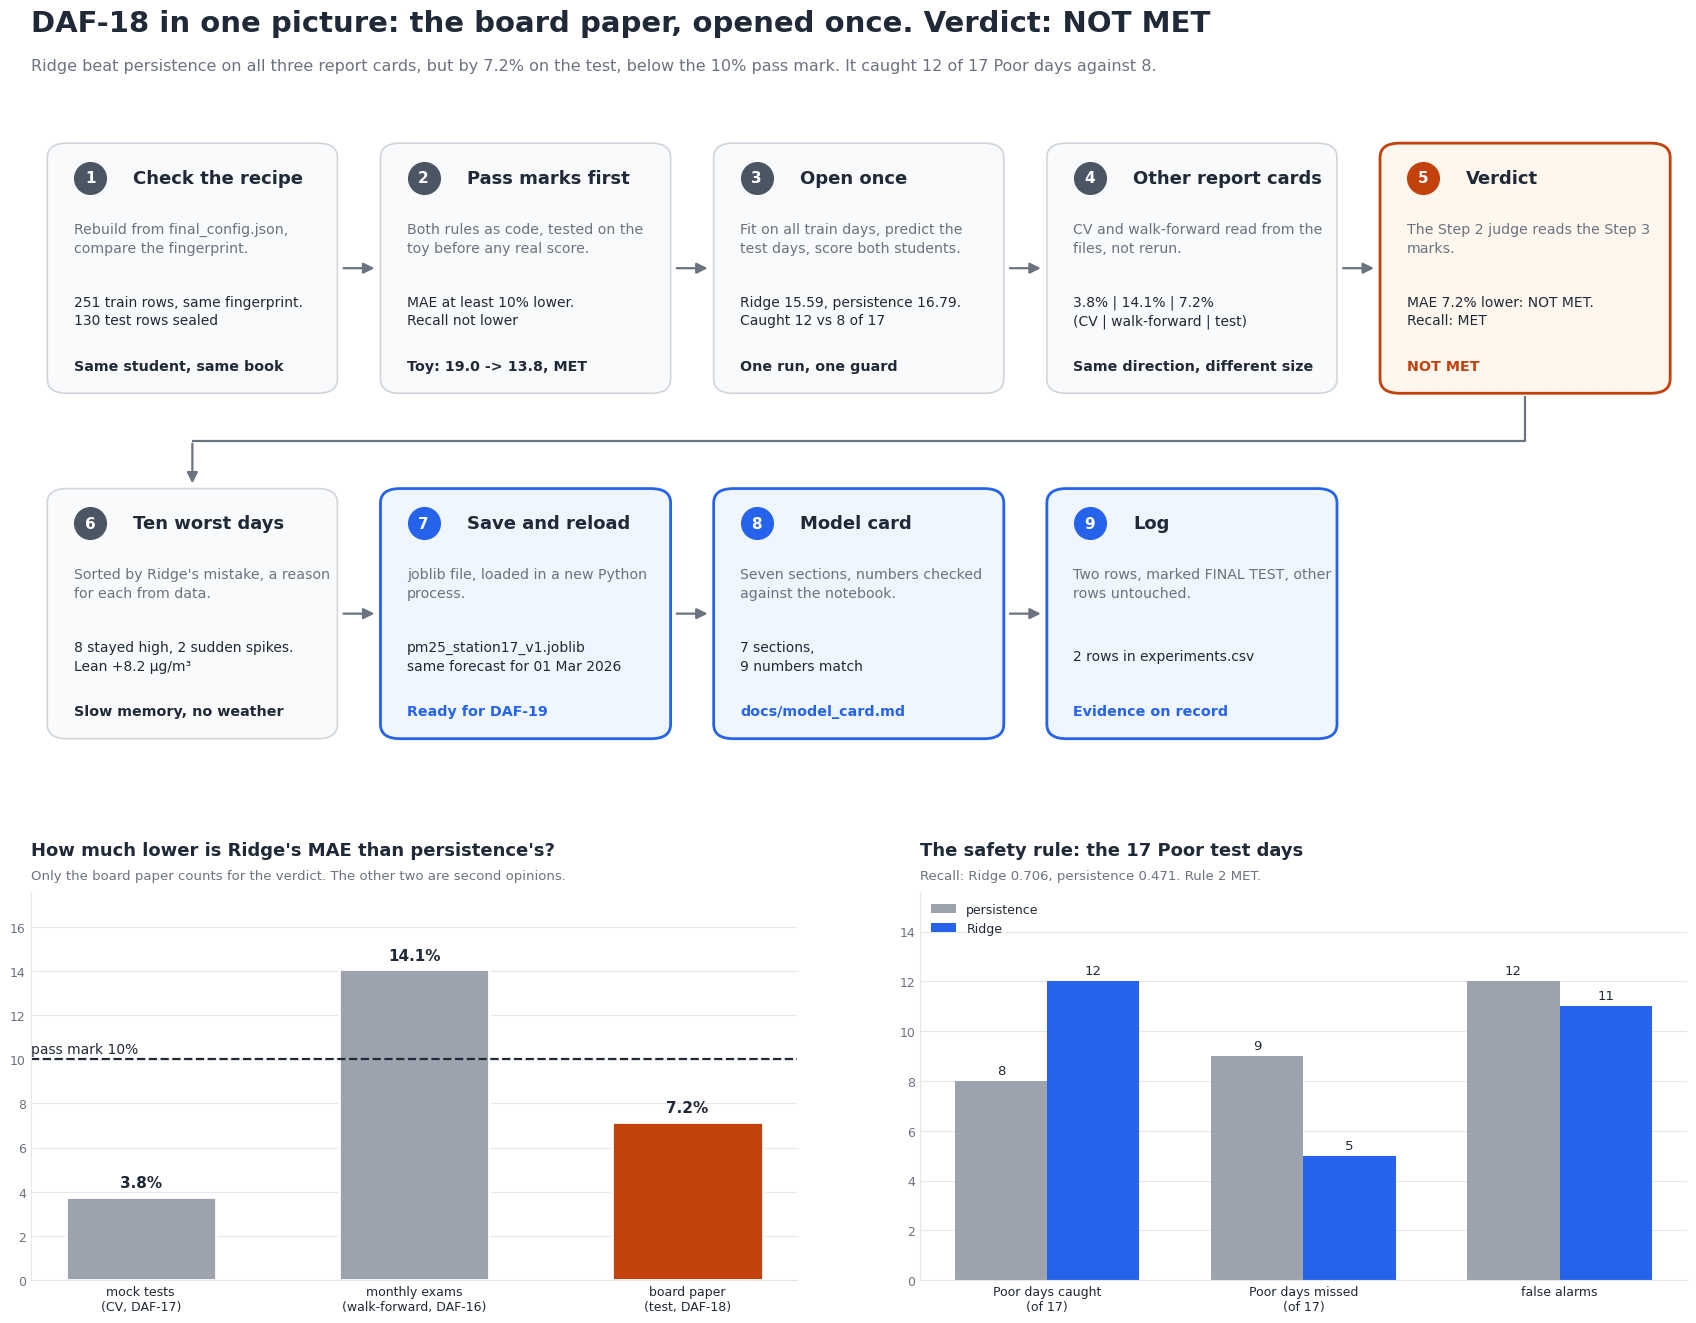

In [11]:
import matplotlib.pyplot as plt

import recap_style as rs

# Continues from Steps 1 to 9. Every number comes from an earlier variable.
r, p = scores.loc["ridge"], scores.loc["persistence"]
cards = [
    dict(badge="1", title="Check the recipe", adds="Rebuild from final_config.json, compare the fingerprint.",
         numbers=f"{len(train)} train rows, same fingerprint.\n{len(test)} test rows sealed", verdict="Same student, same book"),
    dict(badge="2", title="Pass marks first", adds="Both rules as code, tested on the toy before any real score.",
         numbers=f"MAE at least {MIN_MAE_IMPROVEMENT:.0%} lower.\nRecall not lower", verdict="Toy: 19.0 -> 13.8, MET"),
    dict(badge="3", title="Open once", adds="Fit on all train days, predict the test days, score both students.",
         numbers=f"Ridge {r['MAE']:.2f}, persistence {p['MAE']:.2f}.\nCaught {int(r['caught'])} vs {int(p['caught'])} of {int(r['Poor days'])}", verdict="One run, one guard"),
    dict(badge="4", title="Other report cards", adds="CV and walk-forward read from the files, not rerun.",
         numbers=" | ".join(f"{v:.1f}%" for v in report_cards["gap %"]) + "\n(CV | walk-forward | test)", verdict="Same direction, different size"),
    dict(badge="5", title="Verdict", adds="The Step 2 judge reads the Step 3 marks.",
         numbers=f"MAE {improvement:.1%} lower: {met(rule_1)}.\nRecall: {met(rule_2)}", verdict=f"{VERDICT}", kind="problem"),
    dict(badge="6", title="Ten worst days", adds="Sorted by Ridge's mistake, a reason for each from data.",
         numbers=f"{int((worst['pattern'] == HIGH).sum())} stayed high, {int((worst['pattern'] == SPIKE).sum())} sudden spikes.\nLean {bias['ridge_error']:+.1f} µg/m³", verdict="Slow memory, no weather"),
    dict(badge="7", title="Save and reload", adds="joblib file, loaded in a new Python process.",
         numbers=f"{model_path.name}\nsame forecast for {check_day:%d %b %Y}", verdict="Ready for DAF-19", kind="final"),
    dict(badge="8", title="Model card", adds="Seven sections, numbers checked against the notebook.",
         numbers=f"{len(required_sections)} sections,\n{len(must_appear)} numbers match", verdict="docs/model_card.md", kind="final"),
    dict(badge="9", title="Log", adds="Two rows, marked FINAL TEST, other rows untouched.",
         numbers=f"{len(daf18)} rows in experiments.csv", verdict="Evidence on record", kind="final"),
]

flow_h = rs.flow_size(len(cards), 5)
fig = plt.figure(figsize=(rs.FIG_W, flow_h + 5.4), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[flow_h, 5.4], hspace=0.28, wspace=0.16, left=0.05, right=0.97, top=0.9, bottom=0.08)
rs.header(fig, f"DAF-18 in one picture: the board paper, opened once. Verdict: {VERDICT}",
          f"Ridge beat persistence on all three report cards, but by {improvement:.1%} on the test, below the 10% pass mark. "
          f"It caught {int(r['caught'])} of {int(r['Poor days'])} Poor days against {int(p['caught'])}.")
rs.draw_cards(fig.add_subplot(grid[0, :]), cards, cols=5)

# Left: the gain on each report card against the pass mark
left = fig.add_subplot(grid[1, 0])
labels = ["mock tests\n(CV, DAF-17)", "monthly exams\n(walk-forward, DAF-16)", "board paper\n(test, DAF-18)"]
gains = report_cards["gap %"].to_list()
bars = left.bar(labels, gains, width=0.55, color=[rs.BAR, rs.BAR, rs.ALERT if not rule_1 else rs.ACCENT], edgecolor="white", linewidth=2)
for bar, gain in zip(bars, gains):
    left.text(bar.get_x() + bar.get_width() / 2, gain + 0.3, f"{gain:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold", color=rs.INK)
left.axhline(100 * MIN_MAE_IMPROVEMENT, color=rs.INK, ls="--", lw=1.6)
left.text(-0.4, 100 * MIN_MAE_IMPROVEMENT + 0.3, f"pass mark {MIN_MAE_IMPROVEMENT:.0%}", fontsize=10, color=rs.INK)
left.set_ylim(0, max(gains) * 1.25)
rs.style_axis(left, "How much lower is Ridge's MAE than persistence's?", "Only the board paper counts for the verdict. The other two are second opinions.")

# Right: the 17 Poor days and the false alarms
right = fig.add_subplot(grid[1, 1])
kinds = ["caught", "missed", "false alarms"]
x_pos = range(len(kinds))
for offset, name, marks, colour in ((-0.18, "persistence", p, rs.BAR), (0.18, "Ridge", r, rs.ACCENT)):
    bars = right.bar([x + offset for x in x_pos], [marks[k] for k in kinds], 0.36, color=colour)
    rs.label_bars(right, bars)
right.set_xticks(list(x_pos), [f"Poor days caught\n(of {int(r['Poor days'])})", f"Poor days missed\n(of {int(r['Poor days'])})", "false alarms"])
right.set_ylim(0, max(r["false alarms"], p["false alarms"], r["caught"]) * 1.3)
rs.whole_numbers(right)
rs.legend(right, [("persistence", rs.BAR, "bar"), ("Ridge", rs.ACCENT, "bar")], loc="upper left")
rs.style_axis(right, "The safety rule: the 17 Poor test days", f"Recall: Ridge {r['recall']:.3f}, persistence {p['recall']:.3f}. Rule 2 {met(rule_2)}.")
fig.savefig("figures/18_recap.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

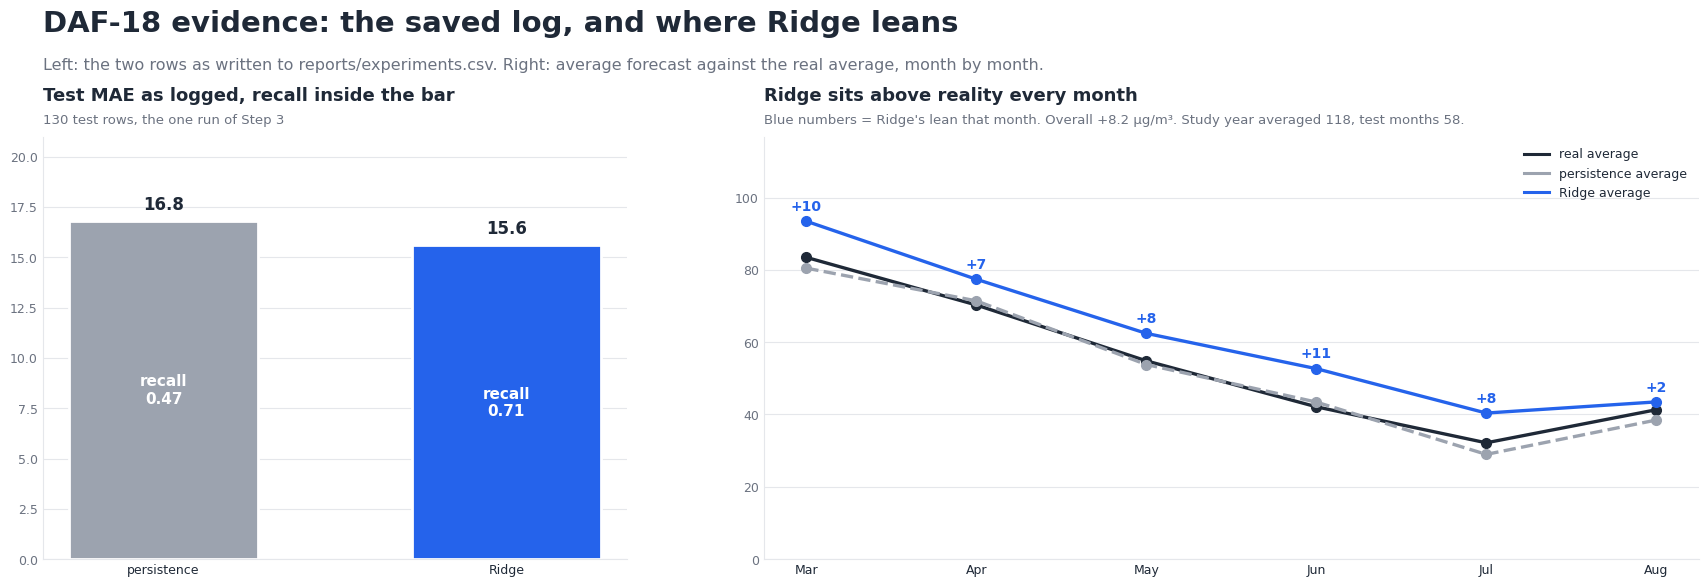

In [12]:
# The evidence figure: the saved log rows, and the lean month by month.
root = rs.find_project_root()
saved_log = pd.read_csv(root / "reports/experiments.csv")
daf18_rows = saved_log.loc[saved_log["ticket"] == "DAF-18"].set_index("model")
assert len(daf18_rows) == 2 and daf18_rows["notes"].str.contains("FINAL TEST, scored once").all()

fig = plt.figure(figsize=(rs.FIG_W, 6.6), facecolor="white")
grid = fig.add_gridspec(1, 2, width_ratios=[1, 1.6], wspace=0.18, left=0.05, right=0.97, top=0.78, bottom=0.14)
rs.header(fig, "DAF-18 evidence: the saved log, and where Ridge leans",
          "Left: the two rows as written to reports/experiments.csv. Right: average forecast against the real average, month by month.")

log_ax = fig.add_subplot(grid[0, 0])
names = ["daf18_persistence_test", "daf18_ridge_test"]
bars = log_ax.bar(["persistence", "Ridge"], daf18_rows.loc[names, "mae"], width=0.55, color=[rs.BAR, rs.ACCENT], edgecolor="white", linewidth=2)
for bar, name in zip(bars, names):
    log_ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f"{daf18_rows.loc[name, 'mae']:.1f}", ha="center", va="bottom",
                fontsize=12, fontweight="bold", color=rs.INK)
    log_ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f"recall\n{daf18_rows.loc[name, 'recall_poor']:.2f}", ha="center",
                va="center", fontsize=11, fontweight="bold", color="white")
log_ax.set_ylim(0, daf18_rows["mae"].max() * 1.25)
rs.style_axis(log_ax, "Test MAE as logged, recall inside the bar", "130 test rows, the one run of Step 3")

lean_ax = fig.add_subplot(grid[0, 1])
monthly_means = test_result.groupby(test_result.index.to_period("M"))[["actual", "ridge", "persistence"]].mean()
months = [m.strftime("%b") for m in monthly_means.index]
for column, colour, style, label in (("actual", rs.INK, "-", "real average"), ("persistence", rs.BAR, "--", "persistence average"),
                                     ("ridge", rs.ACCENT, "-", "Ridge average")):
    lean_ax.plot(months, monthly_means[column], style, color=colour, lw=2.4, marker="o", ms=7, label=label)
for x, (_, row) in enumerate(by_month.iterrows()):
    lean_ax.text(x, monthly_means["ridge"].iloc[x] + 3, f"{row['ridge_lean']:+.0f}", ha="center", fontsize=10, color=rs.ACCENT, fontweight="bold")
lean_ax.set_ylim(0, monthly_means.max().max() * 1.25)
rs.legend(lean_ax, [("real average", rs.INK, "line"), ("persistence average", rs.BAR, "line"), ("Ridge average", rs.ACCENT, "line")], loc="upper right")
rs.style_axis(lean_ax, "Ridge sits above reality every month", f"Blue numbers = Ridge's lean that month. Overall {bias['ridge_error']:+.1f} µg/m³. "
              f"Study year averaged {train[TARGET].mean():.0f}, test months {test_result['actual'].mean():.0f}.")
fig.savefig("figures/18_evidence.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

### What the recap shows

- **The envelope was opened once.** One cell scored the 130 test days, with a guard against a second run. Everything after it only read those marks.
- **The pass marks came first.** They were written as code and tested on the toy before any real number existed, so the verdict could not bend.
- **Verdict: NOT MET.** Ridge's MAE was 7.2% lower than persistence's (15.59 vs 16.79), below the 10% pass mark. On safety it passed clearly: 12 of 17 Poor days caught against 8.
- **The other report cards agree on direction, not size.** 3.8% in cross-validation, 14.1% in walk-forward, 7.2% on the test. Better every time, clearly 10% better only once.
- **The mistakes have a shape.** The air cleaning up after smog (8 of the 10 worst days), sudden spikes with no warning (2 of 10, both Poor), and a +8.2 µg/m³ lean in clean months. All three point to missing information, mainly weather, rather than wrong settings.
- **The model travels.** `models/pm25_station17_v1.joblib` reproduces its forecast in a fresh Python, and `docs/model_card.md` tells the next person when not to trust it.

If you remember only one thing: score the test once against rules written beforehand, report the result as it is, even when it is NOT MET, and write down where the model fails, because that is what the next version and the next user need most.